# Laboratorio 6: análisis de redes sociales en YouTube

**Documento final completo**  
**Integrantes:** Milton Polanco y Osman de León

En este notebook se trabajan la carga, integración, limpieza, análisis exploratorio, la red bipartita autor-video (ejercicios 1 a 4), sus proyecciones, la topología y fragmentación, la detección de comunidades, la centralidad y los participantes puente, el análisis de sentimiento, y las conclusiones finales (ejercicios 5 a 10).

## 0. Configuración

Se definen rutas, estilo gráfico, palabras vacías y funciones auxiliares. Los identificadores permanecen como texto y nunca se sustituyen por nombres visibles.

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import re
import unicodedata
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIGURES = ROOT / "reporte" / "figuras"
TABLES = ROOT / "reporte" / "tablas"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "figure.dpi": 140,
        "savefig.dpi": 220,
    }
)
sns.set_theme(style="whitegrid", font="serif")


STOPWORDS = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "aquel",
    "aquella", "aquellas", "aquello", "aquellos", "aqui", "asi", "aun",
    "aunque", "bajo", "bien", "cada", "casi", "como", "con", "contra",
    "cual", "cuando", "de", "del", "desde", "donde", "dos", "durante",
    "e", "el", "ella", "ellas", "ello", "ellos", "en", "entre", "era",
    "eran", "es", "esa", "esas", "ese", "eso", "esos", "esta", "estan",
    "estar", "este", "esto", "estos", "fue", "fuera", "fueron", "ha",
    "hace", "hacia", "han", "hasta", "hay", "la", "las", "le", "les",
    "lo", "los", "mas", "me", "mi", "mis", "mismo", "mucho", "muy",
    "nada", "ni", "no", "nos", "nuestra", "nuestro", "o", "otra", "otro",
    "para", "pero", "poco", "por", "porque", "que", "quien", "se", "sea",
    "ser", "si", "sin", "sobre", "son", "su", "sus", "tambien", "te",
    "tiene", "todo", "tu", "un", "una", "uno", "unos", "usted", "ya", "y",
    "yo", "video", "youtube"
}


def fold(text: str) -> str:
    """Version sin tildes para comparar nombres, no para reemplazar IDs."""
    return "".join(
        c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c)
    ).casefold().strip()


def split_hashtag(match: re.Match[str]) -> str:
    tag = match.group(1).replace("_", " ")
    tag = re.sub(r"(?<=[a-záéíóúñ])(?=[A-ZÁÉÍÓÚÑ])", " ", tag)
    return " " + tag + " "


def clean_text(value: object) -> str:
    text = str(value)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text, flags=re.I)
    text = re.sub(r"#([\wÁÉÍÓÚÜÑáéíóúüñ]+)", split_hashtag, text)
    text = re.sub(r"@[\w.\-]+", " ", text)
    text = text.casefold()
    # Conserva letras y tildes; elimina cifras, puntuacion y emojis.
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    tokens = [t for t in text.split() if len(t) > 1 and fold(t) not in STOPWORDS]
    return " ".join(tokens)


def parse_count(value: object, blank_is_zero: bool = False) -> float:
    """Convierte conteos con comas, puntos y sufijos K/M a numero."""
    text = str(value).strip().lower().replace("vistas", "").strip()
    if not text:
        return 0.0 if blank_is_zero else np.nan
    text = text.replace("\u00a0", "").replace(" ", "")
    multiplier = 1.0
    if text.endswith("k"):
        multiplier, text = 1_000.0, text[:-1]
    elif text.endswith("m"):
        multiplier, text = 1_000_000.0, text[:-1]
    if multiplier == 1.0:
        text = text.replace(",", "").replace(".", "")
    else:
        text = text.replace(",", ".")
    try:
        return float(text) * multiplier
    except ValueError:
        return np.nan


def shorten(text: str, length: int = 52) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text if len(text) <= length else text[: length - 1].rstrip() + "…"


def savefig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES / name, bbox_inches="tight", facecolor="white")
    plt.close()

## 1. Carga, comprensión e integración

Cada fila de `youtube_videos.csv` representa un video y su llave es `video_id`. Cada fila de `youtube_comments.csv` representa un comentario principal y su llave es `comment_id`. La integración se valida como muchos-a-uno mediante `video_id`.

In [2]:
videos = pd.read_csv(DATA / "youtube_videos.csv", keep_default_na=False)
comments = pd.read_csv(DATA / "youtube_comments.csv", keep_default_na=False)

# Copias de auditoria antes de cualquier transformacion.
videos_raw = videos.copy()
comments_raw = comments.copy()

# Normalizacion conservadora: espacios externos en identificadores y campos visibles.
for col in ["video_id", "channel_id", "comment_id", "author_channel_id"]:
    target = videos if col in videos.columns else comments
    target[col] = target[col].astype(str).str.strip()
for col in ["title", "channel_name", "channel_handle", "owner_handle"]:
    videos[col] = videos[col].astype(str).str.strip()
for col in ["video_title", "channel_name", "author_name", "author_handle"]:
    comments[col] = comments[col].astype(str).str.strip()

videos["view_count_parsed"] = videos["view_count_text"].map(parse_count)
comments["like_count"] = comments["like_count_text"].map(
    lambda x: parse_count(x, blank_is_zero=True)
).astype("Int64")
comments["reply_count"] = pd.to_numeric(comments["reply_count"], errors="coerce").astype("Int64")
videos["publish_date"] = pd.to_datetime(videos["publish_date"], errors="coerce", utc=True)
videos["upload_date"] = pd.to_datetime(videos["upload_date"], errors="coerce", utc=True)

comments["texto_original"] = comments["text"].astype(str)
comments["texto_limpio"] = comments["texto_original"].map(clean_text)

# Integracion many-to-one: conserva un comentario por fila.
video_lookup_cols = [
    "video_id", "title", "channel_name", "channel_id", "category", "view_count",
    "publish_date", "channel_handle"
]
integrated = comments.merge(
    videos[video_lookup_cols], on="video_id", how="left", validate="many_to_one",
    indicator=True, suffixes=("_comentario", "_video")
)

In [3]:
display(pd.DataFrame({
    'conjunto': ['videos', 'comentarios', 'integrado'],
    'filas': [len(videos_raw), len(comments_raw), len(integrated)],
    'columnas': [videos_raw.shape[1], comments_raw.shape[1], integrated.shape[1]]
}))
display(integrated['_merge'].value_counts().rename_axis('resultado').reset_index(name='comentarios'))

,conjunto,filas,columnas
0,videos,293,20
1,comentarios,406,17
2,integrado,406,28


,resultado,comentarios
0,both,406
1,left_only,0
2,right_only,0


## 2. Calidad, limpieza y preprocesamiento

Se revisan dimensiones, vacíos, duplicados, constantes, valores atípicos y consistencia entre identificadores y etiquetas. Los atípicos se diagnostican, pero no se eliminan porque son plausibles en conteos de plataforma.

In [4]:
def quality_rows(df: pd.DataFrame, dataset: str, primary_key: str) -> list[dict]:
    return [
        {"conjunto": dataset, "indicador": "filas", "valor": len(df)},
        {"conjunto": dataset, "indicador": "columnas", "valor": df.shape[1]},
        {"conjunto": dataset, "indicador": "faltantes/celdas vacias", "valor": int(df.isna().sum().sum() + (df.astype(str).apply(lambda s: s.str.strip().eq("")).sum().sum()))},
        {"conjunto": dataset, "indicador": "filas duplicadas", "valor": int(df.duplicated().sum())},
        {"conjunto": dataset, "indicador": f"{primary_key} duplicada", "valor": int(df[primary_key].duplicated().sum())},
        {"conjunto": dataset, "indicador": "variables constantes", "valor": int((df.nunique(dropna=False) <= 1).sum())},
    ]


quality = pd.DataFrame(
    quality_rows(videos_raw, "videos", "video_id")
    + quality_rows(comments_raw, "comentarios", "comment_id")
)
quality.to_csv(TABLES / "diagnostico_calidad.csv", index=False, encoding="utf-8-sig")

missing = []
for dataset, df in [("videos", videos_raw), ("comentarios", comments_raw)]:
    for col in df.columns:
        n = int(df[col].isna().sum() + df[col].astype(str).str.strip().eq("").sum())
        if n:
            missing.append({"conjunto": dataset, "variable": col, "faltantes": n, "porcentaje": 100 * n / len(df)})
pd.DataFrame(missing).to_csv(TABLES / "valores_faltantes.csv", index=False, encoding="utf-8-sig")

constants = []
for dataset, df in [("videos", videos_raw), ("comentarios", comments_raw)]:
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            constants.append({"conjunto": dataset, "variable": col, "valor": str(df[col].iloc[0])})
pd.DataFrame(constants).to_csv(TABLES / "variables_constantes.csv", index=False, encoding="utf-8-sig")


def iqr_outliers(series: pd.Series) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return {
        "q1": float(q1), "mediana": float(s.median()), "q3": float(q3),
        "limite_superior": float(upper), "atipicos_superiores": int((s > upper).sum()),
        "maximo": float(s.max())
    }


outlier_table = pd.DataFrame(
    [
        {"variable": "view_count", **iqr_outliers(videos["view_count"])},
        {"variable": "like_count", **iqr_outliers(comments["like_count"])},
        {"variable": "reply_count", **iqr_outliers(comments["reply_count"])},
    ]
)
outlier_table.to_csv(TABLES / "diagnostico_atipicos.csv", index=False, encoding="utf-8-sig")

# Consistencia entre llaves y campos redundantes.
matched = integrated["_merge"].eq("both")
channel_id_mismatch = matched & integrated["channel_id_comentario"].ne(integrated["channel_id_video"])
channel_name_mismatch = matched & integrated["channel_name_comentario"].map(fold).ne(integrated["channel_name_video"].map(fold))
title_mismatch = matched & integrated["video_title"].map(fold).ne(integrated["title"].map(fold))


def ambiguous_mapping(df: pd.DataFrame, key: str, value: str) -> int:
    return int((df.groupby(key)[value].nunique() > 1).sum())


consistency = pd.DataFrame(
    [
        {"comprobacion": "comentarios asociados a video", "valor": int(matched.sum())},
        {"comprobacion": "comentarios sin video", "valor": int((~matched).sum())},
        {"comprobacion": "diferencias channel_id al integrar", "valor": int(channel_id_mismatch.sum())},
        {"comprobacion": "diferencias channel_name al integrar", "valor": int(channel_name_mismatch.sum())},
        {"comprobacion": "diferencias de titulo al integrar", "valor": int(title_mismatch.sum())},
        {"comprobacion": "channel_id con mas de un nombre (videos)", "valor": ambiguous_mapping(videos, "channel_id", "channel_name")},
        {"comprobacion": "channel_id con mas de un handle (videos)", "valor": ambiguous_mapping(videos, "channel_id", "channel_handle")},
        {"comprobacion": "author_channel_id con mas de un nombre", "valor": ambiguous_mapping(comments, "author_channel_id", "author_name")},
        {"comprobacion": "author_channel_id con mas de un handle", "valor": ambiguous_mapping(comments, "author_channel_id", "author_handle")},
        {"comprobacion": "publish_date distinta de upload_date", "valor": int(videos["publish_date"].ne(videos["upload_date"]).sum())},
        {"comprobacion": "owner_handle distinto de channel_handle", "valor": int(videos["owner_handle"].ne(videos["channel_handle"]).sum())},
    ]
)
consistency.to_csv(TABLES / "consistencia.csv", index=False, encoding="utf-8-sig")

view_valid = videos["view_count_parsed"].notna()
view_mismatch = view_valid & videos["view_count_parsed"].ne(videos["view_count"])

In [5]:
display(quality)
display(pd.DataFrame(missing))
display(pd.DataFrame(constants))
display(outlier_table)
display(consistency)

,conjunto,indicador,valor
0,videos,filas,293
1,videos,columnas,20
2,videos,faltantes/celdas vacias,77
3,videos,filas duplicadas,0
4,videos,video_id duplicada,0
5,videos,variables constantes,0
6,comentarios,filas,406
7,comentarios,columnas,17
8,comentarios,faltantes/celdas vacias,595
9,comentarios,filas duplicadas,0


,conjunto,variable,faltantes,porcentaje
0,videos,published_time,13,4.436860
1,videos,view_count_text,13,4.436860
2,videos,description_snippet,25,8.532423
3,videos,description,26,8.873720
4,comentarios,like_count_text,189,46.551724
5,comentarios,viewer_rating,406,100.000000


,conjunto,variable,valor
0,comentarios,is_pinned,False
1,comentarios,viewer_rating,


,variable,q1,mediana,q3,limite_superior,atipicos_superiores,maximo
0,view_count,215.0,1175.0,7465.0,18340.0,49,8190449.0
1,like_count,0.0,1.0,2.0,5.0,48,405.0
2,reply_count,0.0,0.0,0.0,0.0,30,7.0


,comprobacion,valor
0,comentarios asociados a video,406
1,comentarios sin video,0
2,diferencias channel_id al integrar,0
3,diferencias channel_name al integrar,0
4,diferencias de titulo al integrar,0
5,channel_id con mas de un nombre (videos),0
6,channel_id con mas de un handle (videos),0
7,author_channel_id con mas de un nombre,0
8,author_channel_id con mas de un handle,0
9,publish_date distinta de upload_date,0


### Efecto de la limpieza textual

`texto_original` conserva el comentario para auditoría. `texto_limpio` elimina URL, menciones, puntuación, cifras, emojis y palabras vacías; los hashtags se separan y se conservan como términos. No se aplica lematización sin un modelo contextual validado para español guatemalteco.

In [6]:
# Cuantificacion de limpieza de texto.
text_effect = {
    "registros": len(comments),
    "modificados": int(comments["texto_original"].ne(comments["texto_limpio"]).sum()),
    "vacios_antes": int(comments["texto_original"].str.strip().eq("").sum()),
    "vacios_despues": int(comments["texto_limpio"].str.strip().eq("").sum()),
    "duplicados_antes": int(comments["texto_original"].duplicated().sum()),
    "duplicados_despues": int(comments["texto_limpio"].duplicated().sum()),
    "registros_eliminados": 0,
}
pd.DataFrame([text_effect]).to_csv(TABLES / "efecto_limpieza_texto.csv", index=False, encoding="utf-8-sig")

In [7]:
display(pd.DataFrame([text_effect]))
display(comments[['texto_original', 'texto_limpio']].head(10))

,registros,modificados,vacios_antes,vacios_despues,duplicados_antes,duplicados_despues,registros_eliminados
0,406,403,0,6,2,12,0


,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo vieja fiscal tengo verbose carcel
1,"Están jóvenes porque no buscan un trabajo, tu...",jóvenes buscan trabajo tuvieron suerte policía...
2,Me dejaron con ganas de demandar la ilegalidad...,dejaron ganas demandar ilegalidad reuniones vi...
3,Veremos a este mafioso de Mazariegos en la cár...,veremos mafioso mazariegos cárcel buen tiempo ...
4,eso es para que salga de USA por su propio pie...,salga usa propio pie auto deporten
5,Imagine if they had to walk back home.,imagine if they had to walk back home
6,buenísima investigacion :hand-purple-blue-peac...,buenísima investigacion hand purple blue peace...
7,"Lleven su lonchera, sacrifiquense un poco. Y r...",lleven lonchera sacrifiquense reintevren diner...
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala
9,LADRONES !!!!,ladrones


## 3. Análisis exploratorio

Se describen videos, canales, comentarios, autores, categorías, consultas, visualizaciones, respuestas, me gusta, palabras, bigramas y hashtags.

In [8]:
# Resumen exploratorio.
n_videos = videos["video_id"].nunique()
n_channels = videos["channel_id"].nunique()
n_comments = comments["comment_id"].nunique()
n_authors = comments["author_channel_id"].nunique()
n_commented_videos = comments["video_id"].nunique()

overview = pd.DataFrame(
    {
        "elemento": ["Videos", "Canales", "Comentarios", "Autores", "Videos con comentarios"],
        "cantidad": [n_videos, n_channels, n_comments, n_authors, n_commented_videos],
    }
)
overview.to_csv(TABLES / "resumen_general.csv", index=False, encoding="utf-8-sig")

videos_by_channel = (
    videos.groupby(["channel_id", "channel_name"], as_index=False)
    .agg(videos=("video_id", "nunique"), visualizaciones=("view_count", "sum"))
    .sort_values(["videos", "visualizaciones"], ascending=False)
)
videos_by_channel.to_csv(TABLES / "videos_por_canal.csv", index=False, encoding="utf-8-sig")

per_video = (
    comments.groupby("video_id", as_index=False)
    .agg(comentarios=("comment_id", "nunique"), autores=("author_channel_id", "nunique"), respuestas=("reply_count", "sum"), me_gusta=("like_count", "sum"))
    .merge(videos[["video_id", "title", "channel_name", "channel_id", "view_count", "category"]], on="video_id", how="right")
    .fillna({"comentarios": 0, "autores": 0, "respuestas": 0, "me_gusta": 0})
)
for col in ["comentarios", "autores", "respuestas", "me_gusta"]:
    per_video[col] = per_video[col].astype(int)
per_video.sort_values(["comentarios", "view_count"], ascending=False).to_csv(
    TABLES / "resumen_por_video.csv", index=False, encoding="utf-8-sig"
)

channel_participation = (
    per_video.groupby(["channel_id", "channel_name"], as_index=False)
    .agg(videos=("video_id", "nunique"), comentarios=("comentarios", "sum"), autores=("autores", "sum"), visualizaciones=("view_count", "sum"))
    .sort_values(["comentarios", "visualizaciones"], ascending=False)
)
# Autores unicos a nivel canal (evita sumar duplicados entre videos).
channel_unique_authors = comments.groupby("channel_id")["author_channel_id"].nunique()
channel_participation["autores_unicos"] = channel_participation["channel_id"].map(channel_unique_authors).fillna(0).astype(int)
channel_participation.to_csv(TABLES / "resumen_por_canal.csv", index=False, encoding="utf-8-sig")

category_summary = (
    per_video.groupby("category", as_index=False)
    .agg(videos=("video_id", "nunique"), visualizaciones=("view_count", "sum"), comentarios=("comentarios", "sum"))
    .sort_values("videos", ascending=False)
)
category_summary.to_csv(TABLES / "resumen_categorias.csv", index=False, encoding="utf-8-sig")

query_summary = (
    videos.groupby(["source_group", "source_query"], as_index=False)
    .agg(videos=("video_id", "nunique"), visualizaciones=("view_count", "sum"))
    .sort_values("videos", ascending=False)
)
query_summary.to_csv(TABLES / "resumen_consultas.csv", index=False, encoding="utf-8-sig")

all_clean_tokens = [token for text in comments["texto_limpio"] for token in text.split()]
word_counts = Counter(all_clean_tokens)
bigram_counts = Counter(
    pair for text in comments["texto_limpio"] for pair in zip(text.split(), text.split()[1:])
)

hashtag_counter = Counter()
for series in [videos["title"], videos["description"], comments["texto_original"]]:
    for text in series:
        hashtag_counter.update(tag.casefold() for tag in re.findall(r"#([\wÁÉÍÓÚÜÑáéíóúüñ]+)", str(text)))

pd.DataFrame(word_counts.most_common(30), columns=["palabra", "frecuencia"]).to_csv(
    TABLES / "palabras_frecuentes.csv", index=False, encoding="utf-8-sig"
)
pd.DataFrame(
    [(" ".join(k), v) for k, v in bigram_counts.most_common(30)],
    columns=["bigrama", "frecuencia"]
).to_csv(TABLES / "bigramas_frecuentes.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(hashtag_counter.most_common(30), columns=["hashtag", "frecuencia"]).to_csv(
    TABLES / "hashtags_frecuentes.csv", index=False, encoding="utf-8-sig"
)

In [9]:
display(overview)
display(per_video.sort_values(['comentarios', 'view_count'], ascending=False).head(10))
display(channel_participation.head(10))
display(category_summary)
display(query_summary.head(15))

,elemento,cantidad
0,Videos,293
1,Canales,97
2,Comentarios,406
3,Autores,332
4,Videos con comentarios,19


,video_id,comentarios,autores,respuestas,me_gusta,title,channel_name,channel_id,view_count,category
246,n8iP75gIpmw,161,128,3,358,Qué rico come tu diputado,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,11775,News & Politics
229,j43HgwYFKfk,50,49,0,91,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,10156,News & Politics
38,6W4u8sGEnGM,45,32,11,90,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,UC-ZtFBHzgkYFh7whZkuR_Ag,11670,Entertainment
239,lj983NWyAQY,25,25,16,1697,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,UCXa6LVjBzUtmcM3cwbd9e2w,304089,News & Politics
130,OkXlHx0hx-8,25,18,13,25,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,14200,News & Politics
136,PjmxCj-a9Hg,25,19,4,20,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,UC-ZtFBHzgkYFh7whZkuR_Ag,3628,Entertainment
289,yLZS3JiEBg8,16,16,0,13,Arroz con pollo a la MONOPOLIO,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,1954,News & Politics
4,06mFNPU0aB8,14,13,1,12,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,6692,News & Politics
250,ndAZjHqzzT8,12,10,1,3,Internet: escoger el menos malo,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,717,News & Politics
197,b_Hkrkl3adA,7,7,1,1,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,UCEepOY2svuxbsJ-zsAPT9Fg,5469,News & Politics


,channel_id,channel_name,videos,comentarios,autores,visualizaciones,autores_unicos
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18,256,220,31267,214
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32,70,51,56052,50
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27,25,25,452548,25
44,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,2,25,18,77449,18
50,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,3,14,13,78000,13
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17,7,7,424888,7
87,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7,7,67950,7
66,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2,2,5411,2
27,UCECJDeK0MNapZbpaOzxrUPA,Luisito Comunica,1,0,0,8190449,0
24,UCDfEVbDrimcKw5lfbps915g,De todo Gt,5,0,0,4627528,0


,category,videos,visualizaciones,comentarios
5,News & Politics,138,2165695,335
7,People & Blogs,66,5116257,0
2,Entertainment,48,558349,70
1,Education,19,873680,0
10,Travel & Events,8,660990,0
8,Science & Technology,6,128772,0
6,Nonprofits & Activism,3,602,1
3,Film & Animation,2,2849,0
0,Comedy,1,8190449,0
4,Music,1,5262,0


,source_group,source_query,videos,visualizaciones
10,topic,@GobiernodelaRepublicadeGuatema,18,93188
9,topic,@GobiernodeGuatemala,17,21097
3,official_gov,Ministerio de Comunicaciones Guatemala,16,4674
18,topic,guatemala noticias,16,763121
11,topic,@MunicipalidaddeGuatemala-1551,16,5098
6,official_gov,PMT Guatemala,15,233617
1,official_gov,Conred Guatemala,15,6184
14,topic,Gobierno de la República de Guatemala,15,387403
7,official_gov,Policia Nacional Civil Guatemala,13,462936
22,topic,guatemala transporte,13,13100493


### Concentración, visibilidad y audiencias compartidas

Las coincidencias de autores entre videos son un diagnóstico exploratorio. No sustituyen las proyecciones formales del ejercicio 5.

In [10]:
# Concentracion.
video_comment_counts = per_video.sort_values("comentarios", ascending=False)["comentarios"].to_numpy()
channel_comment_counts = channel_participation.sort_values("comentarios", ascending=False)["comentarios"].to_numpy()


def top_share(values: np.ndarray, n: int) -> float:
    return 100 * values[:n].sum() / values.sum() if values.sum() else 0.0


concentration = pd.DataFrame(
    [
        {"nivel": "video", "grupo": "top 1", "porcentaje_comentarios": top_share(video_comment_counts, 1)},
        {"nivel": "video", "grupo": "top 5", "porcentaje_comentarios": top_share(video_comment_counts, 5)},
        {"nivel": "video", "grupo": "top 10", "porcentaje_comentarios": top_share(video_comment_counts, 10)},
        {"nivel": "canal", "grupo": "top 1", "porcentaje_comentarios": top_share(channel_comment_counts, 1)},
        {"nivel": "canal", "grupo": "top 5", "porcentaje_comentarios": top_share(channel_comment_counts, 5)},
        {"nivel": "canal", "grupo": "top 10", "porcentaje_comentarios": top_share(channel_comment_counts, 10)},
    ]
)
concentration.to_csv(TABLES / "concentracion_comentarios.csv", index=False, encoding="utf-8-sig")

# Relacion entre popularidad y participacion. Spearman evita asumir linealidad.
corr_pearson = float(per_video["view_count"].corr(per_video["comentarios"], method="pearson"))
corr_spearman = float(per_video["view_count"].corr(per_video["comentarios"], method="spearman"))
corr_spearman_commented = float(
    per_video.loc[per_video["comentarios"] > 0, "view_count"].corr(
        per_video.loc[per_video["comentarios"] > 0, "comentarios"], method="spearman"
    )
)

# Audiencias compartidas y autores recurrentes (diagnostico descriptivo; no es la proyeccion formal del ejercicio 5).
author_video_degree = comments.groupby("author_channel_id")["video_id"].nunique().sort_values(ascending=False)
recurring_authors = author_video_degree[author_video_degree > 1]
author_names = comments.drop_duplicates("author_channel_id").set_index("author_channel_id")["author_name"]
recurring_table = recurring_authors.rename("videos_comentados").reset_index()
recurring_table["autor"] = recurring_table["author_channel_id"].map(author_names)
recurring_table.to_csv(TABLES / "autores_recurrentes.csv", index=False, encoding="utf-8-sig")

video_authors = comments.groupby("video_id")["author_channel_id"].apply(set).to_dict()
shared_pairs = []
for left, right in combinations(sorted(video_authors), 2):
    shared = len(video_authors[left] & video_authors[right])
    if shared:
        shared_pairs.append((left, right, shared))
shared_pairs.sort(key=lambda row: row[2], reverse=True)
titles = videos.set_index("video_id")["title"]
shared_df = pd.DataFrame(shared_pairs, columns=["video_id_1", "video_id_2", "autores_compartidos"])
if not shared_df.empty:
    shared_df["video_1"] = shared_df["video_id_1"].map(titles)
    shared_df["video_2"] = shared_df["video_id_2"].map(titles)
shared_df.to_csv(TABLES / "audiencias_compartidas.csv", index=False, encoding="utf-8-sig")

In [11]:
display(concentration)
display(recurring_table)
display(shared_df[['video_1', 'video_2', 'autores_compartidos']] if not shared_df.empty else shared_df)

,nivel,grupo,porcentaje_comentarios
0,video,top 1,39.655172
1,video,top 5,75.369458
2,video,top 10,93.596059
3,canal,top 1,63.054187
4,canal,top 5,96.059113
5,canal,top 10,100.000000


,author_channel_id,videos_comentados,autor
0,UCvcu1kR8xMYy_I1Ty-2mV2Q,3,@hashojea7348
1,UCpsKOkt5iWTbenzeuq7dsmQ,3,@inge_vergueta
2,UCHTGCgY2l-DQJIvlA_cpa_Q,2,@virgiliogarcia3039
3,UCbrtvygfRT6QXqWDNrOf-cA,2,@Alejandro00710
4,UCdFlugHJJa4l3YqWuNRmvXw,2,@MarcosCarillo-b1r
5,UCjZgFEowMBrsjodqfovzdKw,2,@franciscoflores3120
6,UCsUCN0Yq_UyTvKjOJLmNrnQ,2,@moisesvaldez4043
7,UCylqlpsh8ENNM1LqgQ1KbxA,2,@Jel.Awesh.M
8,UCzZ6dDCEsLMXbc5pCFXIprw,2,@josegil3813


,video_1,video_2,autores_compartidos
0,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
1,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
2,Capturan a presuntos delincuentes disfrazados ...,Inician los trabajos de recuperación del Puent...,1
3,Inician los trabajos de recuperación del Puent...,Conferencia de Prensa del Gobierno de Guatemal...,1
4,Conferencia de Prensa del Gobierno de Guatemal...,Qué rico come tu diputado,1
5,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
6,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1
7,Bloqueos en Guatemala este 31 de agosto por al...,Qué rico come tu diputado,1
8,Capturan a ladrón que había quedado grabado mi...,La cooptación de Walter Mazariegos en la USAC,1
9,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1


## 4. Construcción de la red bipartita autor-video

Una arista indica que un autor publicó al menos un comentario principal en un video. Su peso es el número de comentarios de ese par. No representa amistad, respuesta directa, conversación ni aprobación.

In [12]:
# Red bipartita completa: 293 videos, incluidos los que no tienen comentarios.
B = nx.Graph()
for row in videos.itertuples(index=False):
    B.add_node(
        f"v:{row.video_id}", tipo="video", video_id=row.video_id,
        etiqueta=row.title, canal=row.channel_name, categoria=row.category,
        visualizaciones=int(row.view_count)
    )
author_meta = comments.drop_duplicates("author_channel_id")
for row in author_meta.itertuples(index=False):
    B.add_node(
        f"a:{row.author_channel_id}", tipo="autor", author_channel_id=row.author_channel_id,
        etiqueta=row.author_name, handle=row.author_handle
    )
edge_counts = (
    comments.groupby(["author_channel_id", "video_id"], as_index=False)
    .agg(peso=("comment_id", "nunique"))
)
for row in edge_counts.itertuples(index=False):
    B.add_edge(f"a:{row.author_channel_id}", f"v:{row.video_id}", peso=int(row.peso))

node_rows = []
for node, attrs in B.nodes(data=True):
    node_rows.append(
        {
            "node_id": node,
            "tipo": attrs["tipo"],
            "etiqueta": attrs.get("etiqueta", ""),
            "grado": B.degree(node),
            "grado_ponderado": int(B.degree(node, weight="peso")),
            "canal": attrs.get("canal", ""),
            "categoria": attrs.get("categoria", ""),
            "visualizaciones": attrs.get("visualizaciones", ""),
            "handle": attrs.get("handle", ""),
        }
    )
pd.DataFrame(node_rows).to_csv(TABLES / "nodos_bipartita.csv", index=False, encoding="utf-8-sig")

edge_table = edge_counts.copy()
edge_table["source"] = "a:" + edge_table["author_channel_id"]
edge_table["target"] = "v:" + edge_table["video_id"]
edge_table["autor"] = edge_table["author_channel_id"].map(author_names)
edge_table["video"] = edge_table["video_id"].map(titles)
edge_table[["source", "target", "peso", "author_channel_id", "video_id", "autor", "video"]].to_csv(
    TABLES / "aristas_bipartita.csv", index=False, encoding="utf-8-sig"
)

In [13]:
display(pd.DataFrame(node_rows).head(10))
display(edge_table[['source', 'target', 'peso', 'autor', 'video']].head(10))
print(f'Nodos: {B.number_of_nodes():,} | Aristas: {B.number_of_edges():,} | Suma de pesos: {sum(d["peso"] for _, _, d in B.edges(data=True)):,}')

,node_id,tipo,etiqueta,grado,grado_ponderado,canal,categoria,visualizaciones,handle
0,v:-5puKGEqcUc,video,INSIVUMEH pronostica incremento de lluvias par...,0,0,T13 Noticias Guatemala,News & Politics,2357,
1,v:-E7OPOLjMug,video,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,0,0,IDocumenta,People & Blogs,4,
2,v:-KDglrIzRKo,video,¡HISTÓRICO! Mexico recupera petróleo robado po...,0,0,México Poder,People & Blogs,29736,
3,v:-O4Pa7qS9WQ,video,Viaje completo Ciudad de Guatemala al IRTRA de...,0,0,Guate Maya Trip,Nonprofits & Activism,383,
4,v:06mFNPU0aB8,video,Capturan a presuntos delincuentes disfrazados ...,13,14,Noti7,News & Politics,6692,
5,v:0LTLUY7LBlA,video,Qué debes saber ANTES de viajar a GUATEMALA | ...,0,0,De viaje con Migue,Travel & Events,6099,
6,v:0a4_g1R1-aA,video,Acciones relevantes en el #Resumen24Horas,0,0,PNCdeGuatemala,Science & Technology,15455,
7,v:0b2vfzXdCqs,video,Cadena Nacional del presidente Bernardo Arévalo,0,0,Gobierno de la República de Guatemala,Entertainment,2725,
8,v:0eiVPMexNOo,video,CONRED se pronuncia tras sismos en el territor...,0,0,TN23 Guatemala,News & Politics,1875,
9,v:0iQD8zHxZIg,video,SE FILTRO un AUDIO de PANDILLEROS en Guatemala...,0,0,Tras la Verdad SV,News & Politics,36701,


,source,target,peso,autor,video
0,a:UC-HeUTT6_g-VoiWds2a4H-w,v:6W4u8sGEnGM,1,@JorgeMunoz-gd9et,Inician los trabajos de recuperación del Puent...
1,a:UC-Iul5tDYH_oiAMXQH-KaaQ,v:6W4u8sGEnGM,1,@AlbertoMancilla-p9h,Inician los trabajos de recuperación del Puent...
2,a:UC-QOpE7GOxlXcHZ8b7HbQKA,v:OkXlHx0hx-8,2,@mariaalexander427,EE.UU. envía a mexicanos deportados a Guatemal...
3,a:UC-fiZBS5Gp1eCJd9ucgWnCg,v:j43HgwYFKfk,1,@Tommii.10,La cooptación de Walter Mazariegos en la USAC
4,a:UC-hfX8J5JPJ-dfuakzegMLA,v:n8iP75gIpmw,1,@normaleticiaorozcojuarez2418,Qué rico come tu diputado
5,a:UC-jS_kA9w-OmpupXDx156Rg,v:n8iP75gIpmw,1,@simoncreyesc7579,Qué rico come tu diputado
6,a:UC-pNP6RMFuLg_-x7Ah_0kEA,v:n8iP75gIpmw,1,@almacatalan2717,Qué rico come tu diputado
7,a:UC094EFEmMSdwVa8NQjjYBXg,v:b_Hkrkl3adA,1,@CelestinoQuej-j7k,Bloqueos en Guatemala este 31 de agosto por al...
8,a:UC0HvfEWozTHbwl_iEmJNvVA,v:6W4u8sGEnGM,1,@OttoPalencia-b7r,Inician los trabajos de recuperación del Puent...
9,a:UC0RpuMwkDKJYqgKHtsJRuWQ,v:lj983NWyAQY,1,@sabinamarinaguerra3248,Plan 2032 Ciudad de Guatemala


Nodos: 625 | Aristas: 343 | Suma de pesos: 406


## Visualizaciones del avance

In [ ]:
# Figuras.
topv = per_video.nlargest(10, "comentarios").sort_values("comentarios")
plt.figure(figsize=(7.0, 4.3))
plt.barh([shorten(x, 48) for x in topv["title"]], topv["comentarios"], color="#3f78a8")
plt.xlabel("Comentarios observados")
plt.title("Videos con mayor participacion")
for i, value in enumerate(topv["comentarios"]):
    plt.text(value + 0.4, i, str(value), va="center", fontsize=8)
savefig("01_top_videos_comentarios.png")

topc = channel_participation.nlargest(10, "comentarios").sort_values("comentarios")
plt.figure(figsize=(7.0, 4.0))
plt.barh([shorten(x, 35) for x in topc["channel_name"]], topc["comentarios"], color="#7b4f9d")
plt.xlabel("Comentarios observados")
plt.title("Canales con mayor participacion")
for i, value in enumerate(topc["comentarios"]):
    plt.text(value + 0.4, i, str(value), va="center", fontsize=8)
savefig("02_top_canales_comentarios.png")

sorted_counts = np.sort(video_comment_counts)[::-1]
cum = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
plt.figure(figsize=(6.8, 3.7))
plt.plot(np.arange(1, len(cum) + 1), cum, color="#1f5f3b", linewidth=1.8)
plt.axhline(80, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Numero de videos, ordenados por comentarios")
plt.ylabel("Porcentaje acumulado de comentarios")
plt.title("Concentracion de comentarios por video")
savefig("03_concentracion_videos.png")

plt.figure(figsize=(6.5, 4.2))
plt.scatter(per_video["view_count"] + 1, per_video["comentarios"] + 0.15,
            alpha=0.65, s=24, color="#b05252", edgecolor="none")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Visualizaciones + 1 (escala logaritmica)")
plt.ylabel("Comentarios + 0.15 (escala logaritmica)")
plt.title("Visualizaciones y comentarios por video")
plt.text(0.02, 0.96, f"Spearman = {corr_spearman:.3f}", transform=plt.gca().transAxes, va="top")
savefig("04_vistas_comentarios.png")

fig, axes = plt.subplots(1, 2, figsize=(8.0, 4.0))
words_top = pd.DataFrame(word_counts.most_common(12), columns=["item", "n"]).sort_values("n")
bigrams_top = pd.DataFrame(
    [(" ".join(k), v) for k, v in bigram_counts.most_common(12)], columns=["item", "n"]
).sort_values("n")
axes[0].barh(words_top["item"], words_top["n"], color="#2f6f8f")
axes[0].set_title("Palabras")
axes[0].set_xlabel("Frecuencia")
axes[1].barh(bigrams_top["item"], bigrams_top["n"], color="#ba7b2c")
axes[1].set_title("Bigramas")
axes[1].set_xlabel("Frecuencia")
fig.suptitle("Terminos frecuentes en comentarios limpios", y=1.02)
savefig("05_palabras_bigramas.png")

hashtags_top = pd.DataFrame(hashtag_counter.most_common(12), columns=["hashtag", "n"]).sort_values("n")
plt.figure(figsize=(6.8, 3.6))
if len(hashtags_top):
    plt.barh(hashtags_top["hashtag"], hashtags_top["n"], color="#367a62")
else:
    plt.text(0.5, 0.5, "No se encontraron hashtags", ha="center", va="center")
plt.xlabel("Frecuencia")
plt.title("Hashtags mas frecuentes en videos y comentarios")
savefig("06_hashtags.png")

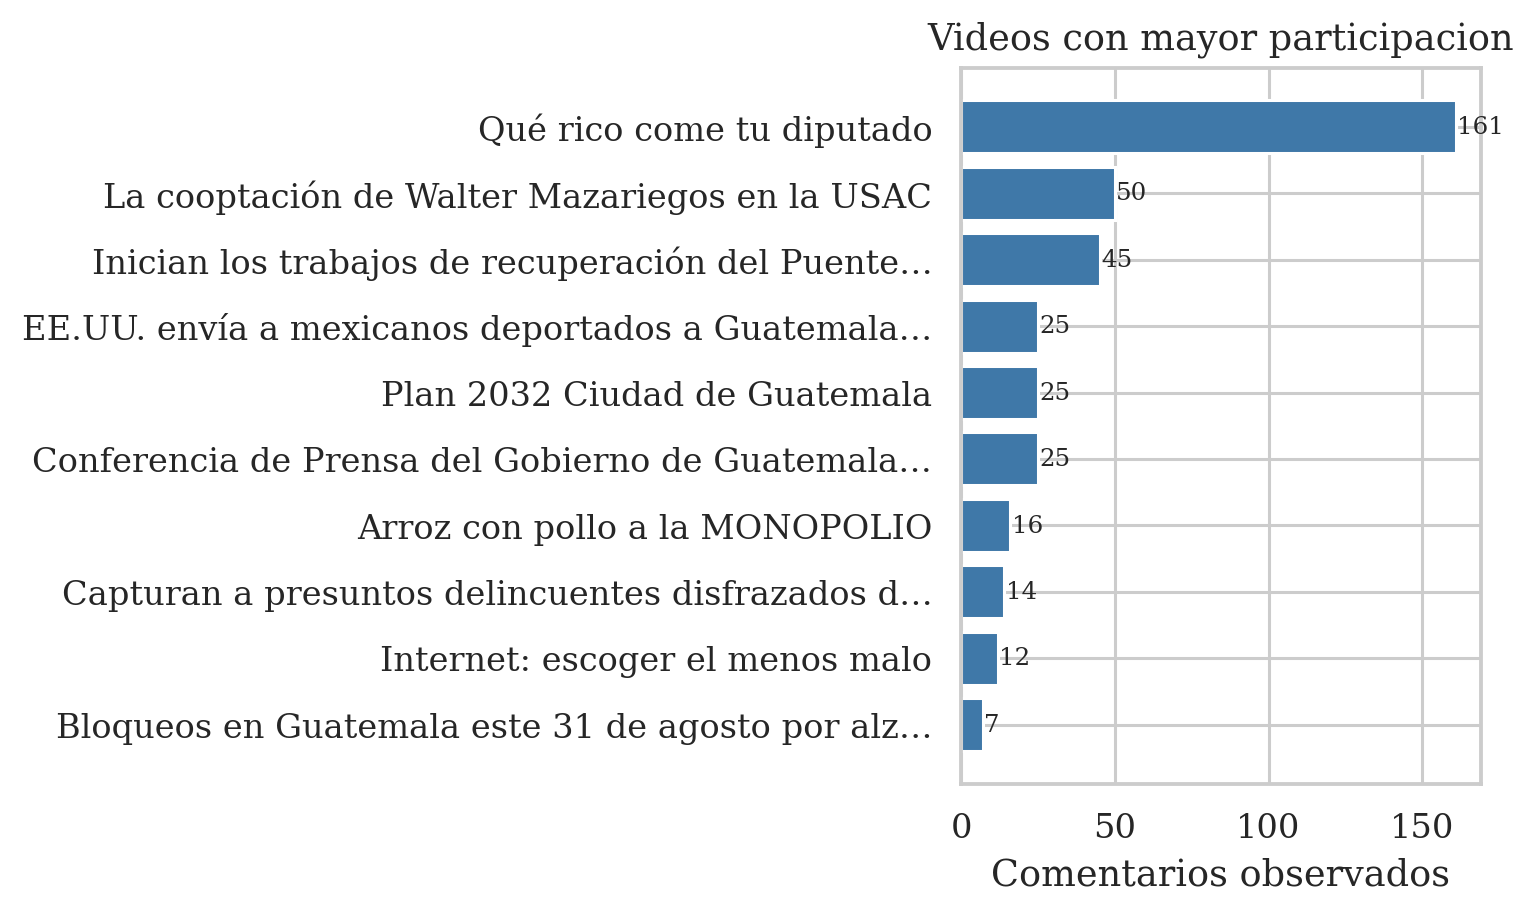

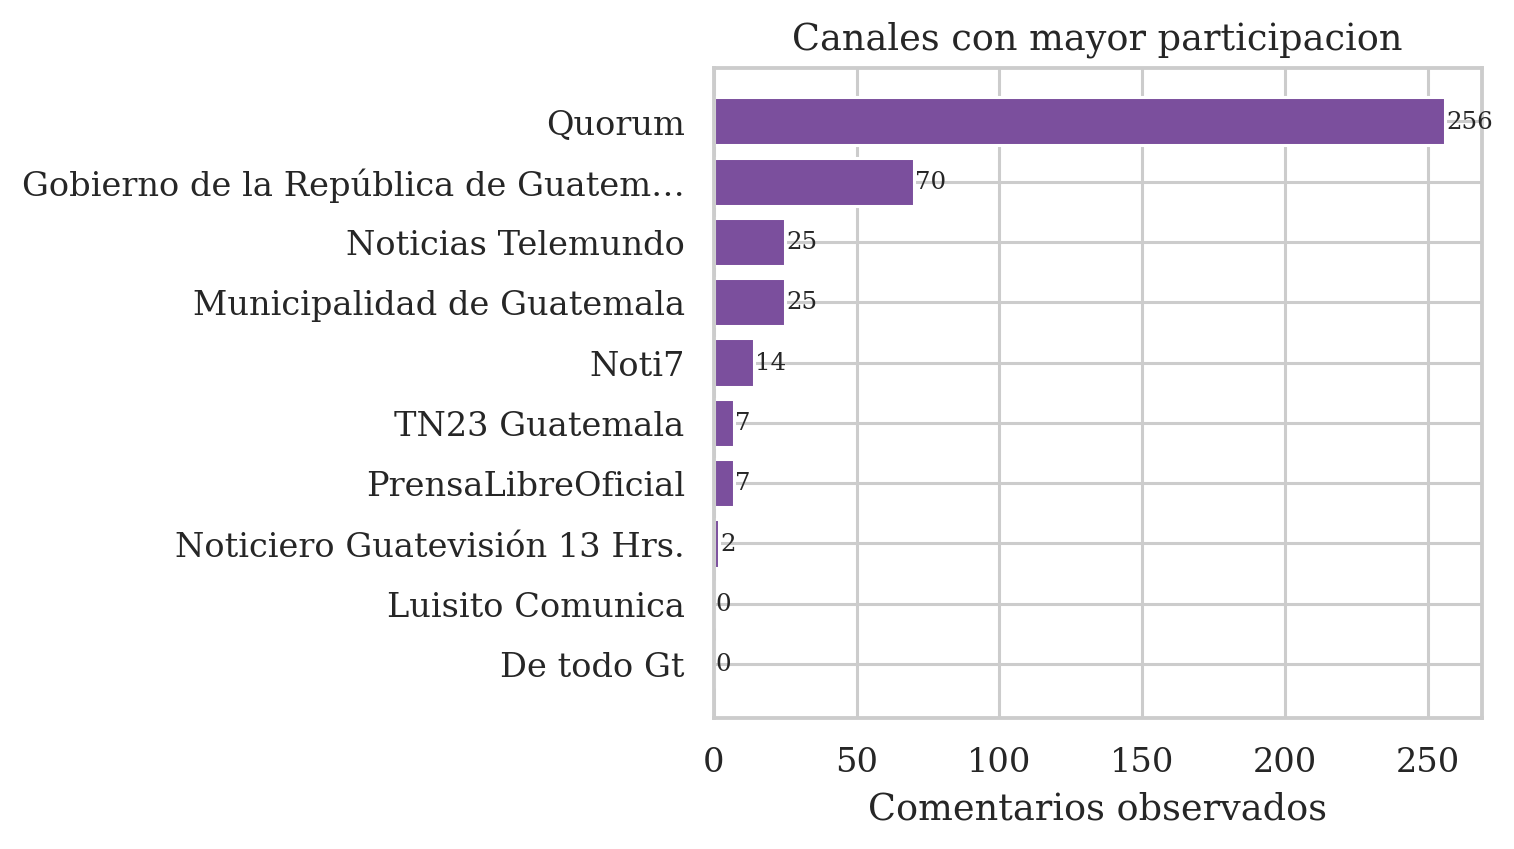

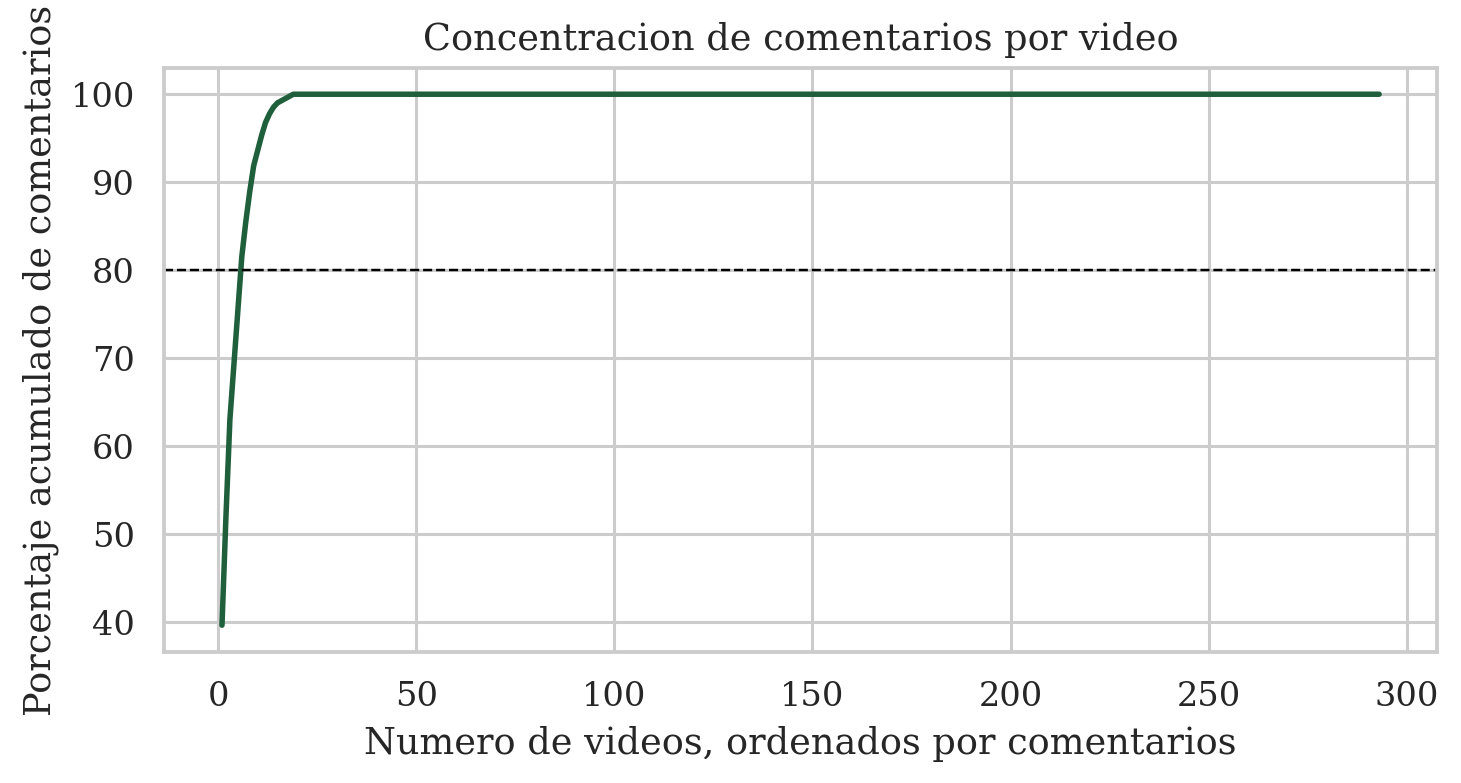

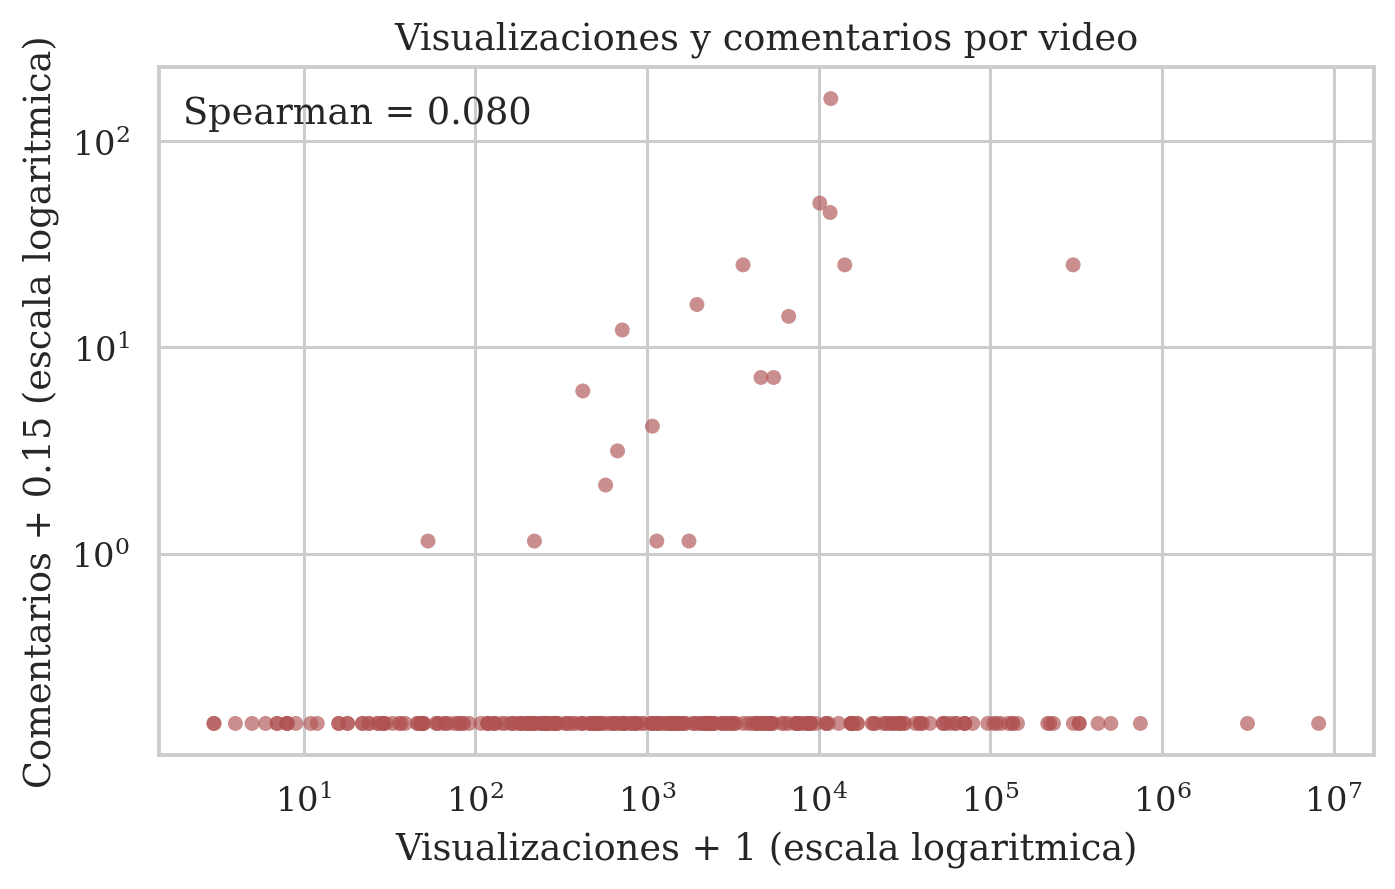

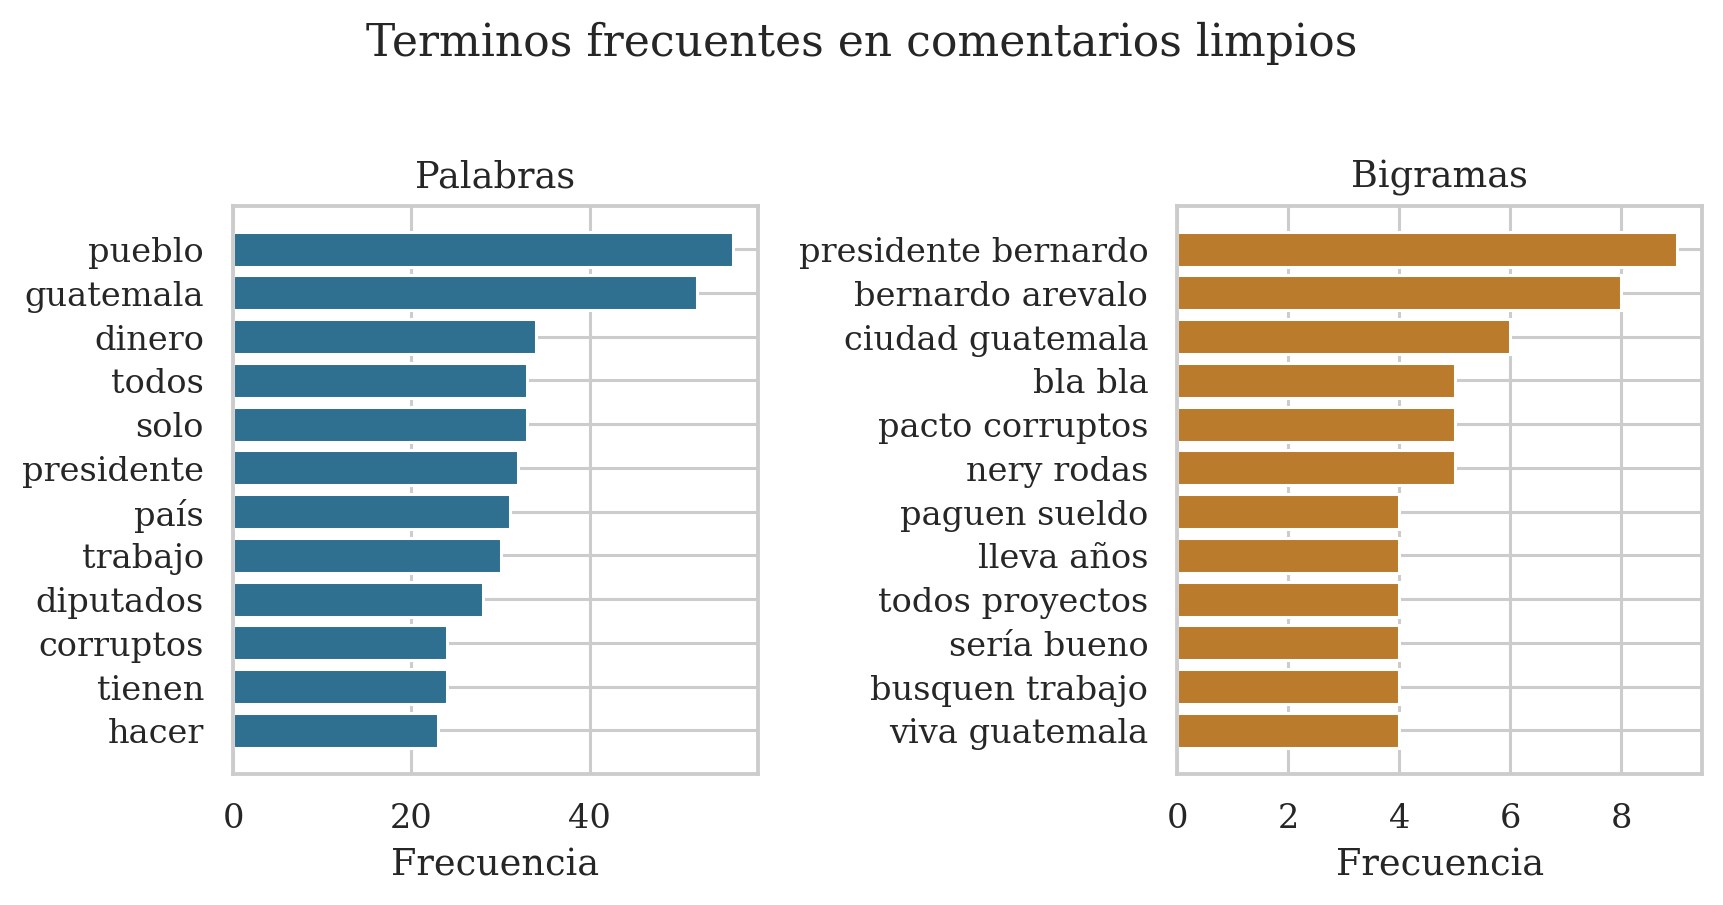

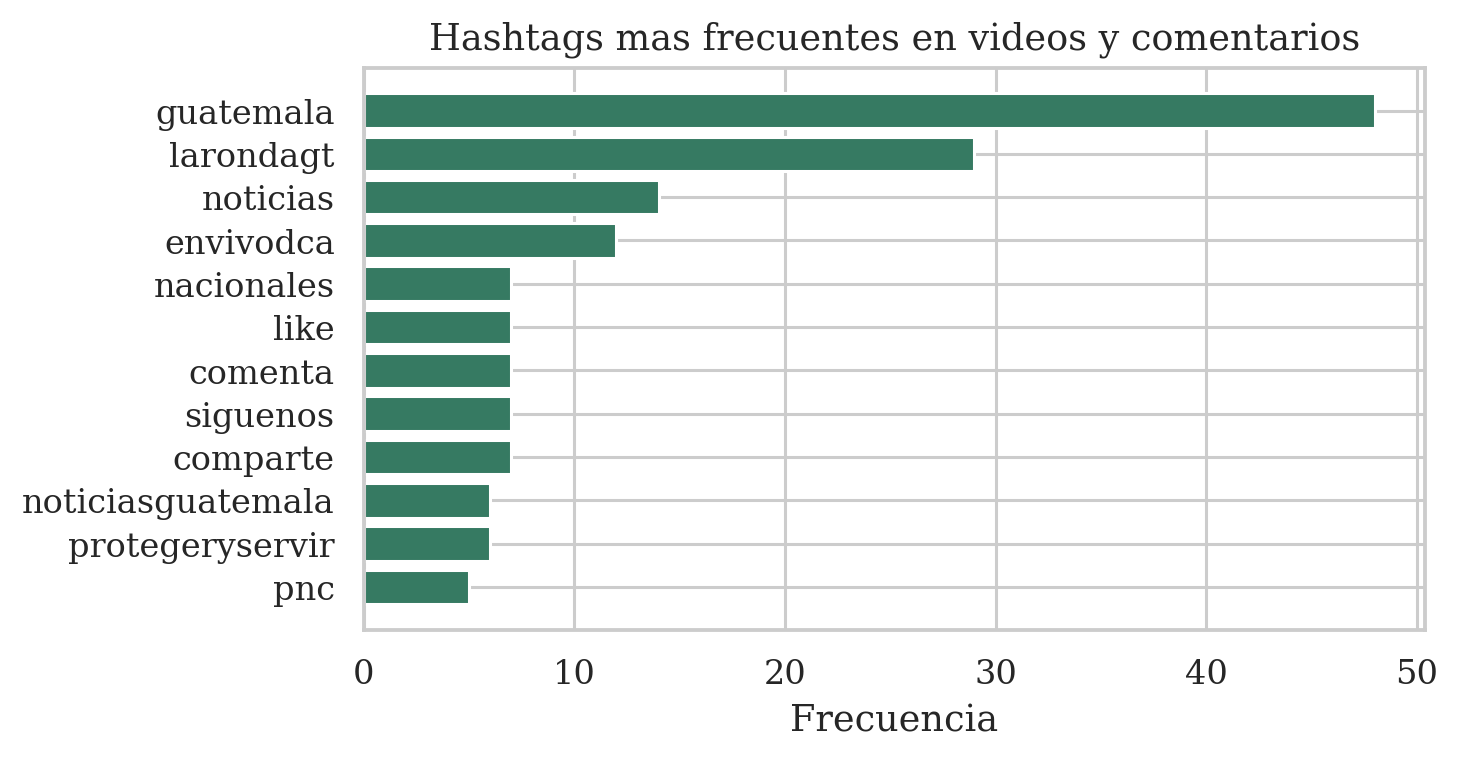

In [ ]:
from IPython.display import Image, display
for archivo in [
    '01_top_videos_comentarios.png',
    '02_top_canales_comentarios.png',
    '03_concentracion_videos.png',
    '04_vistas_comentarios.png',
    '05_palabras_bigramas.png',
    '06_hashtags.png',
]:
    display(Image(filename=str(FIGURES / archivo), width=850))

### Red completa

Se conservan los 293 videos, incluidos aquellos sin comentarios observados, para mostrar la cobertura real de los archivos entregados.

In [ ]:
# Visualizacion completa: posiciones por componentes para mostrar tambien los aislados.
components = sorted(nx.connected_components(B), key=len, reverse=True)
pos = {}
main = B.subgraph(components[0]) if components else B
if len(main):
    main_pos = nx.spring_layout(main, seed=19, k=max(0.12, 2.2 / np.sqrt(len(main))), iterations=130, weight="peso")
    for node, (x, y) in main_pos.items():
        pos[node] = (x * 3.8, y * 3.8)
small_components = components[1:]
cols = 16
for i, comp in enumerate(small_components):
    center = (5.4 + (i % cols) * 0.34, 3.2 - (i // cols) * 0.34)
    if len(comp) == 1:
        pos[next(iter(comp))] = center
    else:
        local = nx.circular_layout(B.subgraph(comp), scale=0.12, center=center)
        pos.update(local)

plt.figure(figsize=(10.5, 7.5))
video_nodes = [n for n, d in B.nodes(data=True) if d["tipo"] == "video"]
author_nodes = [n for n, d in B.nodes(data=True) if d["tipo"] == "autor"]
nx.draw_networkx_edges(B, pos, width=[0.18 + 0.22 * B[u][v]["peso"] for u, v in B.edges()], alpha=0.24, edge_color="#777777")
nx.draw_networkx_nodes(B, pos, nodelist=author_nodes, node_size=9, node_color="#3676a3", alpha=0.80, linewidths=0)
nx.draw_networkx_nodes(B, pos, nodelist=video_nodes, node_size=18, node_color="#c05b43", alpha=0.86, linewidths=0, node_shape="s")
plt.scatter([], [], s=22, color="#3676a3", label="Autor")
plt.scatter([], [], s=30, color="#c05b43", marker="s", label="Video")
plt.legend(frameon=False, loc="lower left")
plt.title("Red bipartita autor-video completa")
plt.axis("off")
savefig("07_red_bipartita_completa.png")

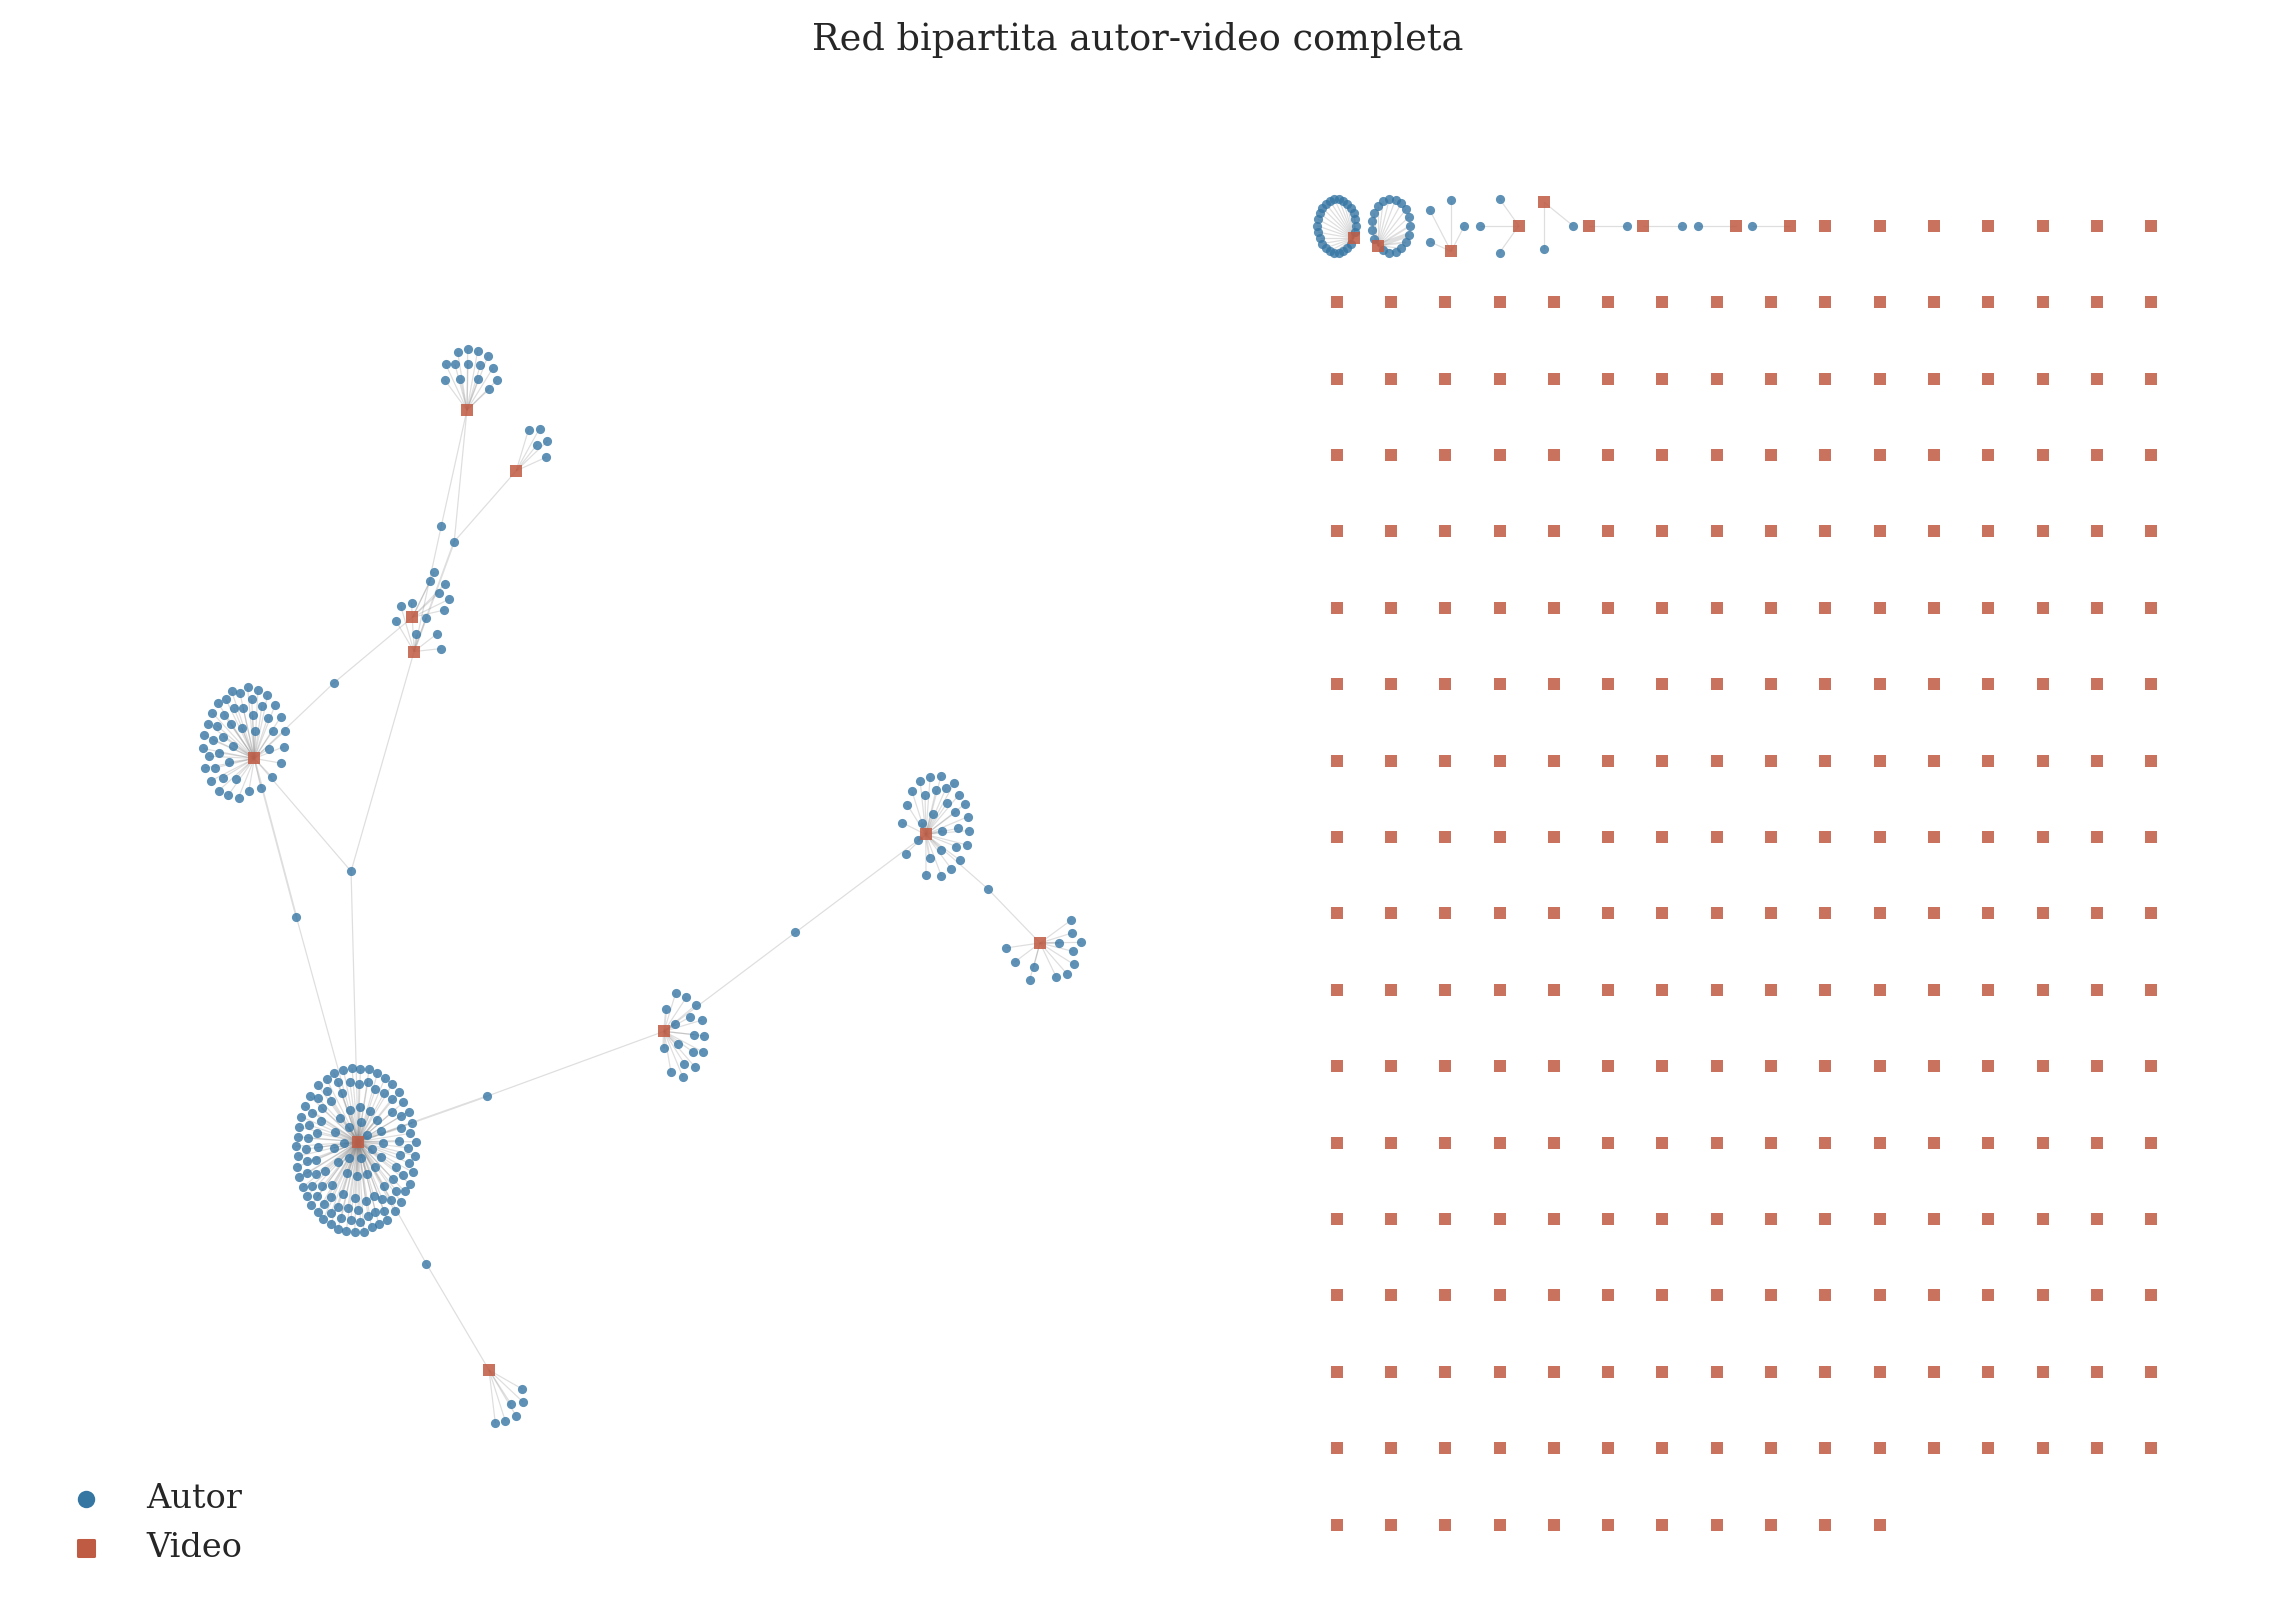

In [ ]:
display(Image(filename=str(FIGURES / '07_red_bipartita_completa.png'), width=1000))

## Exportación de resultados

In [ ]:
# Metricas que alimentan el informe.
nonisolated_components = [c for c in components if len(c) > 1]
articulation = list(nx.articulation_points(B)) if B.number_of_edges() else []
articulation_authors = [n for n in articulation if n.startswith("a:")]
articulation_videos = [n for n in articulation if n.startswith("v:")]

metrics = {
    "videos": n_videos,
    "canales": n_channels,
    "comentarios": n_comments,
    "autores": n_authors,
    "videos_con_comentarios": n_commented_videos,
    "comentarios_integrados": int(matched.sum()),
    "comentarios_sin_video": int((~matched).sum()),
    "view_text_validos": int(view_valid.sum()),
    "view_text_diferencias_con_view_count": int(view_mismatch.sum()),
    "likes_blancos_convertidos_cero": int(comments_raw["like_count_text"].astype(str).str.strip().eq("").sum()),
    "correlacion_pearson_vistas_comentarios": corr_pearson,
    "correlacion_spearman_vistas_comentarios": corr_spearman,
    "correlacion_spearman_solo_comentados": corr_spearman_commented,
    "autores_recurrentes": int(len(recurring_authors)),
    "max_videos_por_autor": int(author_video_degree.max()),
    "pares_video_con_audiencia_compartida": int(len(shared_df)),
    "nodos_bipartita": B.number_of_nodes(),
    "nodos_autor": len(author_nodes),
    "nodos_video": len(video_nodes),
    "aristas_bipartita": B.number_of_edges(),
    "suma_pesos_aristas": int(sum(d["peso"] for _, _, d in B.edges(data=True))),
    "videos_aislados": int(sum(B.degree(n) == 0 for n in video_nodes)),
    "componentes_totales": nx.number_connected_components(B),
    "componentes_no_triviales": len(nonisolated_components),
    "tamano_componente_mayor": len(components[0]) if components else 0,
    "autores_articulacion_preliminar": len(articulation_authors),
    "videos_articulacion_preliminar": len(articulation_videos),
    "texto": text_effect,
    "top_palabras": word_counts.most_common(10),
    "top_bigramas": [(" ".join(k), v) for k, v in bigram_counts.most_common(10)],
    "top_hashtags": hashtag_counter.most_common(10),
}
with (TABLES / "metricas.json").open("w", encoding="utf-8") as fh:
    json.dump(metrics, fh, ensure_ascii=False, indent=2)

# Datos limpios para auditoria y continuacion del laboratorio.
videos.to_csv(DATA / "youtube_videos_limpio.csv", index=False, encoding="utf-8-sig")
comments.to_csv(DATA / "youtube_comments_limpio.csv", index=False, encoding="utf-8-sig")
integrated.drop(columns="_merge").to_csv(DATA / "youtube_integrado.csv", index=False, encoding="utf-8-sig")

print(json.dumps(metrics, ensure_ascii=False, indent=2))

{
  "videos": 293,
  "canales": 97,
  "comentarios": 406,
  "autores": 332,
  "videos_con_comentarios": 19,
  "comentarios_integrados": 406,
  "comentarios_sin_video": 0,
  "view_text_validos": 280,
  "view_text_diferencias_con_view_count": 53,
  "likes_blancos_convertidos_cero": 189,
  "correlacion_pearson_vistas_comentarios": -0.008393070918161022,
  "correlacion_spearman_vistas_comentarios": 0.08032343882513514,
  "correlacion_spearman_solo_comentados": 0.8114968240951833,
  "autores_recurrentes": 9,
  "max_videos_por_autor": 3,
  "pares_video_con_audiencia_compartida": 11,
  "nodos_bipartita": 625,
  "nodos_autor": 332,
  "nodos_video": 293,
  "aristas_bipartita": 343,
  "suma_pesos_aristas": 406,
  "videos_aislados": 274,
  "componentes_totales": 284,
  "componentes_no_triviales": 10,
  "tamano_componente_mayor": 286,
  "autores_articulacion_preliminar": 7,
  "videos_articulacion_preliminar": 15,
  "texto": {
    "registros": 406,
    "modificados": 403,
    "vacios_antes": 0,
   

## Cierre del avance (ejercicios 1 a 4)

Hasta aquí se cubrieron la carga e integración, el diagnóstico de calidad, la limpieza de texto, el análisis exploratorio y la construcción de la red bipartita autor-video. A partir de la siguiente sección se completan las proyecciones, la topología, las comunidades, la centralidad, el sentimiento y las conclusiones finales.

## 5. Proyecciones de la red

Se construyen dos proyecciones a partir de la red bipartita autor-video:

- **Autor-autor**: dos autores se conectan si comentaron en el mismo video. El peso es el número de videos que comparten (no el número de comentarios), siguiendo lo pedido en el enunciado.
- **Video-video**: dos videos se conectan si comparten al menos un autor. El peso es el número de autores distintos que comparten.

Ambas proyecciones se derivan de la co-participación observada; no implican interacción directa entre las personas ni entre los contenidos.

In [ ]:
# ---- Proyeccion autor-autor: peso = numero de videos compartidos ----
author_edge_videos = {}  # (a1,a2) -> set of shared video_ids
for vid, authors in video_authors.items():
    for a1, a2 in combinations(sorted(authors), 2):
        author_edge_videos.setdefault((a1, a2), set()).add(vid)

AA = nx.Graph()
AA.add_nodes_from(author_nodes)
for (a1, a2), vids in author_edge_videos.items():
    AA.add_edge(f"a:{a1}", f"a:{a2}", peso=len(vids), videos_compartidos=sorted(vids))
nx.set_node_attributes(AA, {f"a:{k}": v for k, v in author_names.to_dict().items()}, "etiqueta")

# ---- Proyeccion video-video: peso = numero de autores compartidos ----
author_videos = comments.groupby("author_channel_id")["video_id"].apply(set).to_dict()
video_edge_authors = {}
for author, vids in author_videos.items():
    for v1, v2 in combinations(sorted(vids), 2):
        video_edge_authors.setdefault((v1, v2), set()).add(author)

VV = nx.Graph()
VV.add_nodes_from(video_nodes)
for (v1, v2), auths in video_edge_authors.items():
    VV.add_edge(f"v:{v1}", f"v:{v2}", peso=len(auths), autores_compartidos=sorted(auths))
nx.set_node_attributes(VV, {f"v:{k}": v for k, v in titles.to_dict().items()}, "etiqueta")

print(f"Autor-autor -> nodos: {AA.number_of_nodes()}, aristas: {AA.number_of_edges()}")
print(f"Video-video -> nodos: {VV.number_of_nodes()}, aristas: {VV.number_of_edges()}")

aa_edge_table = pd.DataFrame(
    [
        {"autor_1": u[2:], "autor_2": v[2:], "nombre_1": author_names.get(u[2:], ""),
         "nombre_2": author_names.get(v[2:], ""), "videos_compartidos": d["peso"]}
        for u, v, d in AA.edges(data=True)
    ]
).sort_values("videos_compartidos", ascending=False)

vv_edge_table = pd.DataFrame(
    [
        {"video_1": u[2:], "video_2": v[2:], "titulo_1": titles.get(u[2:], ""),
         "titulo_2": titles.get(v[2:], ""), "autores_compartidos": d["peso"]}
        for u, v, d in VV.edges(data=True)
    ]
).sort_values("autores_compartidos", ascending=False)

aa_edge_table.to_csv(TABLES / "proyeccion_autor_autor.csv", index=False, encoding="utf-8-sig")
vv_edge_table.to_csv(TABLES / "proyeccion_video_video.csv", index=False, encoding="utf-8-sig")

print(aa_edge_table.head(10).to_string(index=False))
print()
print(vv_edge_table.head(10).to_string(index=False))

Autor-autor -> nodos: 332, aristas: 10732
Video-video -> nodos: 293, aristas: 11
                 autor_1                  autor_2       nombre_1                      nombre_2  videos_compartidos
UCvcu1kR8xMYy_I1Ty-2mV2Q UCbrtvygfRT6QXqWDNrOf-cA  @hashojea7348               @Alejandro00710                   2
UCpsKOkt5iWTbenzeuq7dsmQ UCylqlpsh8ENNM1LqgQ1KbxA @inge_vergueta                  @Jel.Awesh.M                   2
UCpsKOkt5iWTbenzeuq7dsmQ UCsGoJEvb-cFPZ2rWoJcXzEQ @inge_vergueta         @sergiohinestroza9709                   1
UCpsKOkt5iWTbenzeuq7dsmQ UCu8_3-Wg-YzNyvHYQDEscfw @inge_vergueta       @RolandoCastroPérez-d7y                   1
UCpsKOkt5iWTbenzeuq7dsmQ UCuXmOjxC-htcprLgeVXz6Tg @inge_vergueta           @jorgeaguilar-bq3uj                   1
UCpsKOkt5iWTbenzeuq7dsmQ UC-hfX8J5JPJ-dfuakzegMLA @inge_vergueta @normaleticiaorozcojuarez2418                   1
UCpsKOkt5iWTbenzeuq7dsmQ UC-jS_kA9w-OmpupXDx156Rg @inge_vergueta             @simoncreyesc7579                   1

In [ ]:
display(aa_edge_table.head(10)[["nombre_1", "nombre_2", "videos_compartidos"]])
display(vv_edge_table.head(10)[["titulo_1", "titulo_2", "autores_compartidos"]])

,nombre_1,nombre_2,videos_compartidos
1528,@hashojea7348,@Alejandro00710,2
7152,@inge_vergueta,@Jel.Awesh.M,2
7149,@inge_vergueta,@sergiohinestroza9709,1
7150,@inge_vergueta,@RolandoCastroPérez-d7y,1
7151,@inge_vergueta,@jorgeaguilar-bq3uj,1
7153,@inge_vergueta,@normaleticiaorozcojuarez2418,1
7154,@inge_vergueta,@simoncreyesc7579,1
7155,@inge_vergueta,@JoseSimilox-p6e,1
7156,@inge_vergueta,@alfonsomorales2653,1
7148,@inge_vergueta,@carloslam5333,1


,titulo_1,titulo_2,autores_compartidos
10,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
7,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
0,Capturan a presuntos delincuentes disfrazados ...,Inician los trabajos de recuperación del Puent...,1
2,Conferencia de Prensa del Gobierno de Guatemal...,Qué rico come tu diputado,1
1,Inician los trabajos de recuperación del Puent...,Conferencia de Prensa del Gobierno de Guatemal...,1
3,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
4,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1
6,Capturan a ladrón que había quedado grabado mi...,La cooptación de Walter Mazariegos en la USAC,1
5,Bloqueos en Guatemala este 31 de agosto por al...,Qué rico come tu diputado,1
8,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1


In [ ]:
aa_components = sorted(nx.connected_components(AA), key=len, reverse=True)
aa_giant = AA.subgraph(aa_components[0]).copy()
pos_aa = nx.spring_layout(aa_giant, seed=7, k=0.35, weight="peso", iterations=200)
plt.figure(figsize=(7.2, 6.2))
weights = [0.15 + 0.35 * aa_giant[u][v]["peso"] for u, v in aa_giant.edges()]
nx.draw_networkx_edges(aa_giant, pos_aa, width=weights, alpha=0.12, edge_color="#888888")
recurring_ids = set(recurring_authors.index)
node_sizes = [55 if n[2:] in recurring_ids else 12 for n in aa_giant.nodes()]
node_colors = ["#c05b43" if n[2:] in recurring_ids else "#3676a3" for n in aa_giant.nodes()]
nx.draw_networkx_nodes(aa_giant, pos_aa, node_size=node_sizes, node_color=node_colors, alpha=0.8, linewidths=0)
plt.title(f"Proyeccion autor-autor (componente principal, n={len(aa_giant)})\ncirculos rojos: los 9 autores recurrentes (comentaron en mas de un video)")
plt.axis("off")
savefig("09_proyeccion_autor_autor.png")


In [ ]:
vv_edges_only = [n for n in VV.nodes() if VV.degree(n) > 0]
VV_sub = VV.subgraph(vv_edges_only).copy()
pos_vv = nx.spring_layout(VV_sub, seed=11, k=0.6, weight="peso", iterations=200)
plt.figure(figsize=(7.5, 6.0))
weights_vv = [0.6 + 1.1 * VV_sub[u][v]["peso"] for u, v in VV_sub.edges()]
nx.draw_networkx_edges(VV_sub, pos_vv, width=weights_vv, alpha=0.55, edge_color="#999999")
nx.draw_networkx_nodes(VV_sub, pos_vv, node_size=140, node_color="#c05b43", node_shape="s", alpha=0.9)
labels_vv = {n: shorten(titles.get(n[2:], n[2:]), 22) for n in VV_sub.nodes()}
nx.draw_networkx_labels(VV_sub, pos_vv, labels=labels_vv, font_size=6.5)
plt.title(f"Proyeccion video-video (nodos con al menos una arista, n={len(VV_sub)})")
plt.axis("off")
savefig("10_proyeccion_video_video.png")

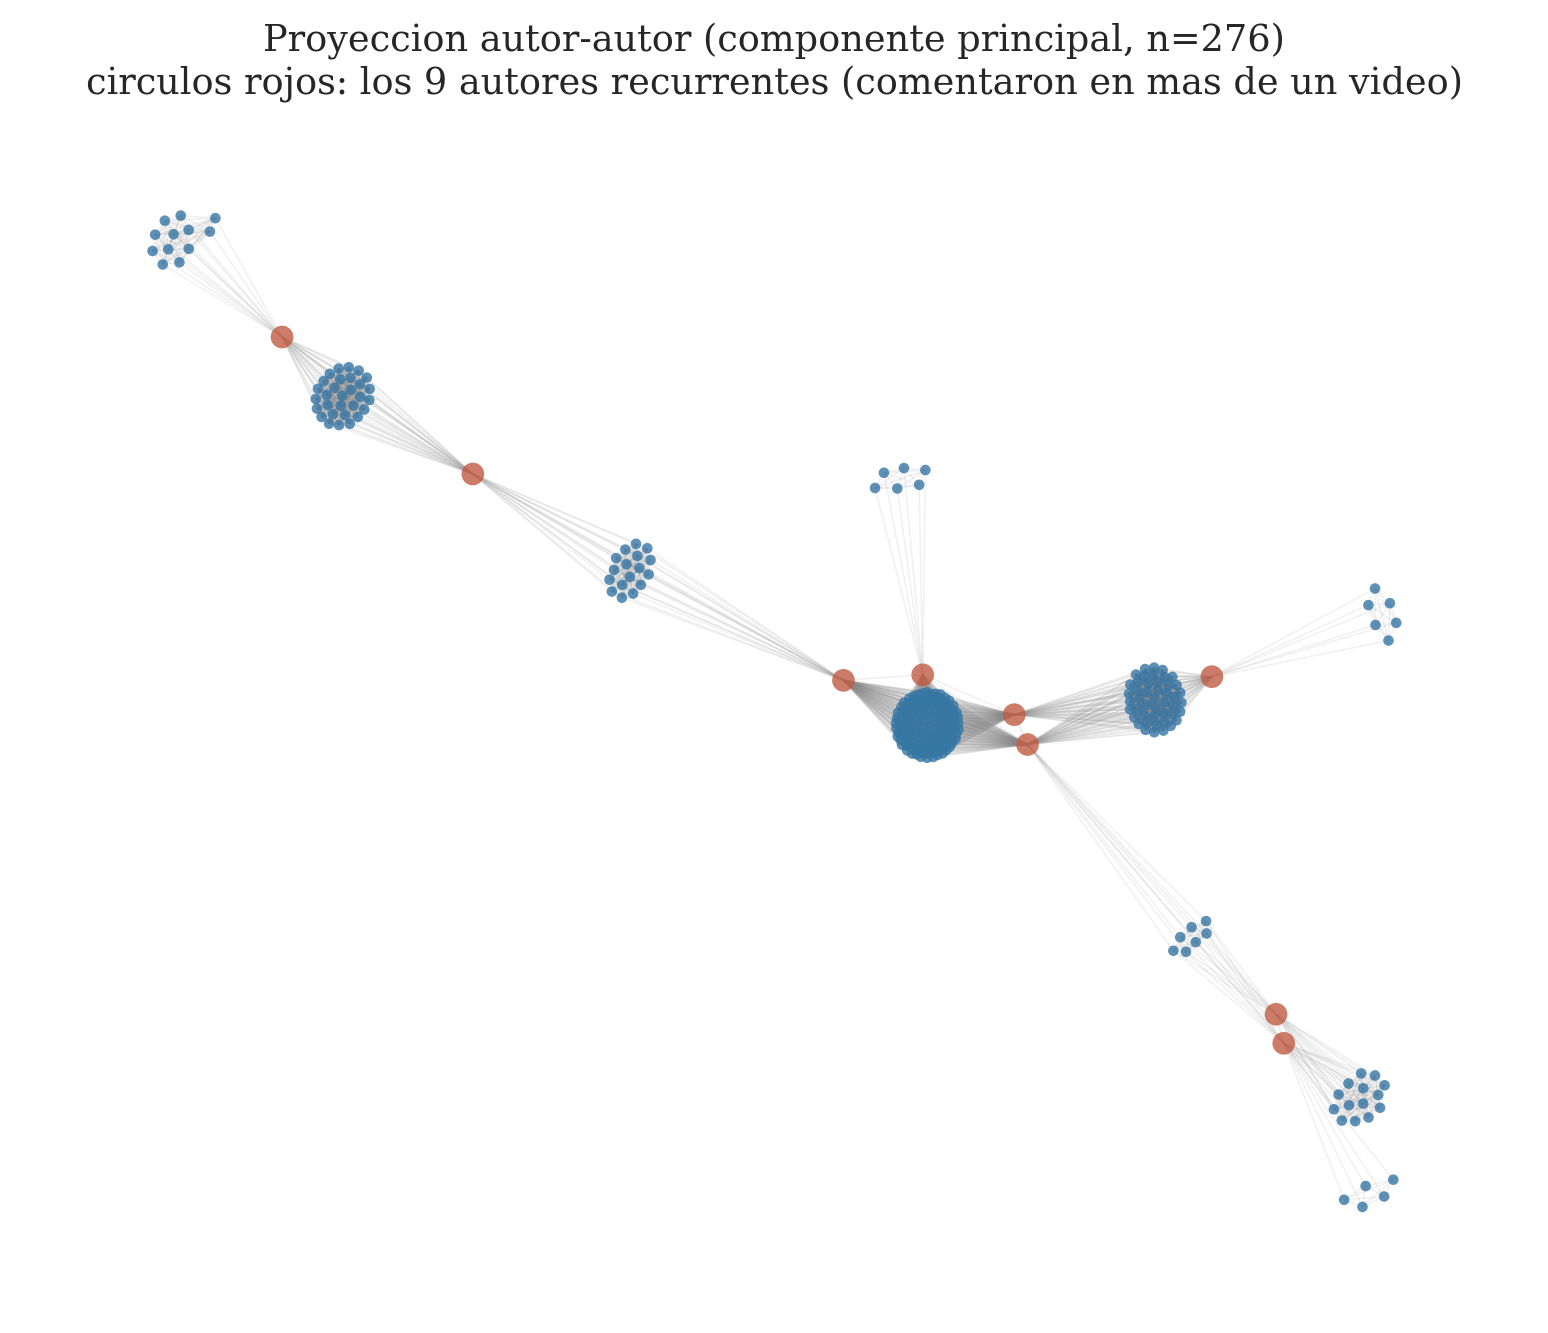

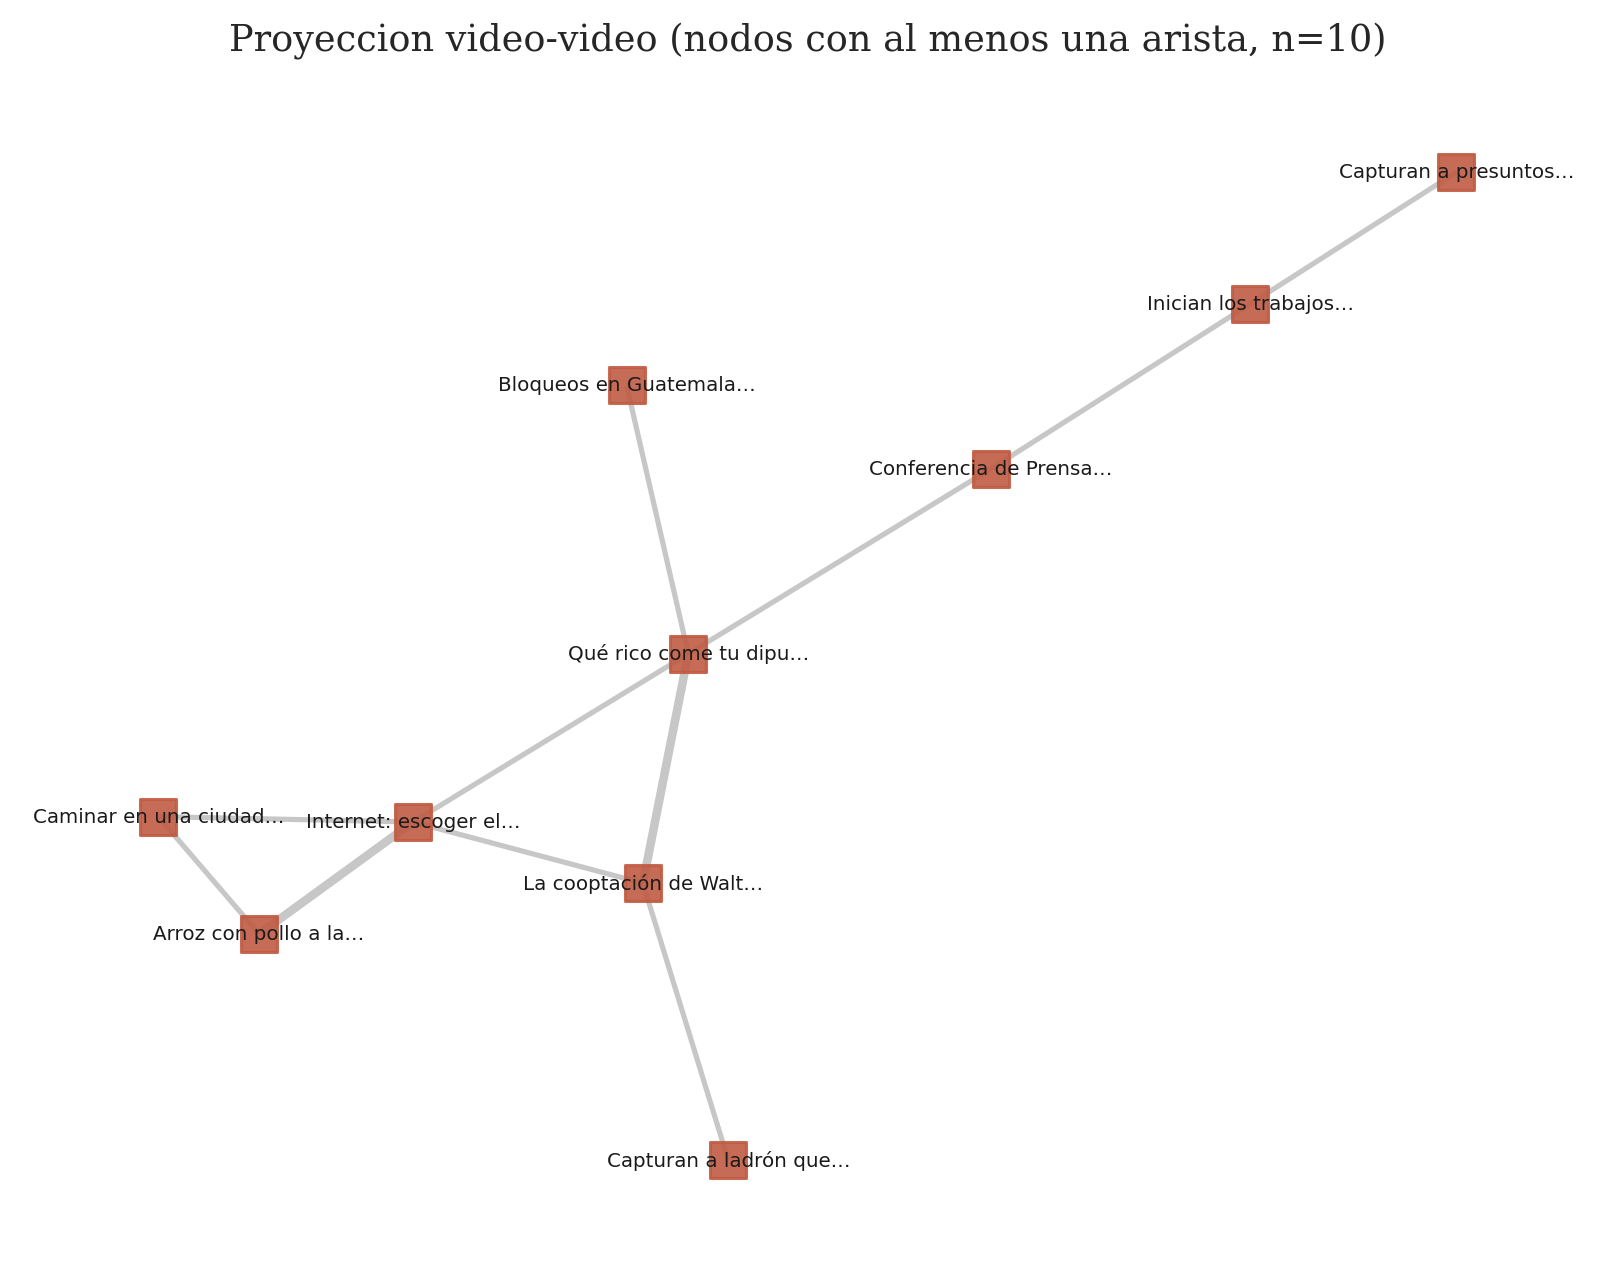

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "09_proyeccion_autor_autor.png"), width=650))
display(Image(filename=str(FIGURES / "10_proyeccion_video_video.png"), width=650))

### Comparación de las proyecciones

La proyección **autor-autor** tiene 332 nodos y **10,732 aristas**: es mucho más densa que la bipartita porque cada video con muchos comentaristas se convierte en una "casi-clique" de autores conectados entre sí (por ejemplo, los 128 autores de "Qué rico come tu diputado" generan por sí solos 8,128 pares posibles). El peso máximo observado es de **2 videos compartidos**: ningún par de autores coincidió en más de dos de los 19 videos con comentarios, lo que confirma que la recurrencia conjunta es marginal aunque la proyección se vea densa.

La proyección **video-video** es, en cambio, extremadamente dispersa: solo **11 aristas** entre 293 videos, y apenas 10 videos quedan conectados a algún otro por al menos un autor en común (máximo 2 autores compartidos por par). Esto es consistente con lo hallado en el avance: las audiencias compartidas entre videos son reales pero muy reducidas.

**Qué representa cada una:** la proyección autor-autor describe *comunidades de comentaristas que conviven en el mismo espacio de discusión* (sin que eso implique que se respondieron entre sí); la proyección video-video describe *solapamiento de audiencia observada* entre piezas de contenido, útil para detectar si el mismo público sigue varios temas o canales.

## 6. Topología y fragmentación

Se calculan número de nodos y aristas, densidad, grado medio, distribución de grados, componentes conexos, cohesión (transitividad/clustering) y nodos periféricos o aislados, tanto para la red bipartita como para sus dos proyecciones.

In [ ]:
author_degrees = sorted([B.degree(n) for n in author_nodes], reverse=True)
video_degrees_nonzero = sorted([B.degree(n) for n in video_nodes if B.degree(n) > 0], reverse=True)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6))
axes[0].hist(author_degrees, bins=range(1, max(author_degrees) + 2), color="#3676a3", align="left")
axes[0].set_title("Grado de autores (bipartita)")
axes[0].set_xlabel("Numero de videos comentados")
axes[0].set_ylabel("Cantidad de autores")
axes[0].set_yscale("log")
axes[1].hist(video_degrees_nonzero, bins=range(1, max(video_degrees_nonzero) + 2), color="#c05b43", align="left")
axes[1].set_title("Grado de videos con comentarios (bipartita)")
axes[1].set_xlabel("Numero de autores distintos")
axes[1].set_ylabel("Cantidad de videos")
fig.suptitle("Distribucion de grados de la red bipartita autor-video", y=1.03)
savefig("08_distribucion_grados_bipartita.png")

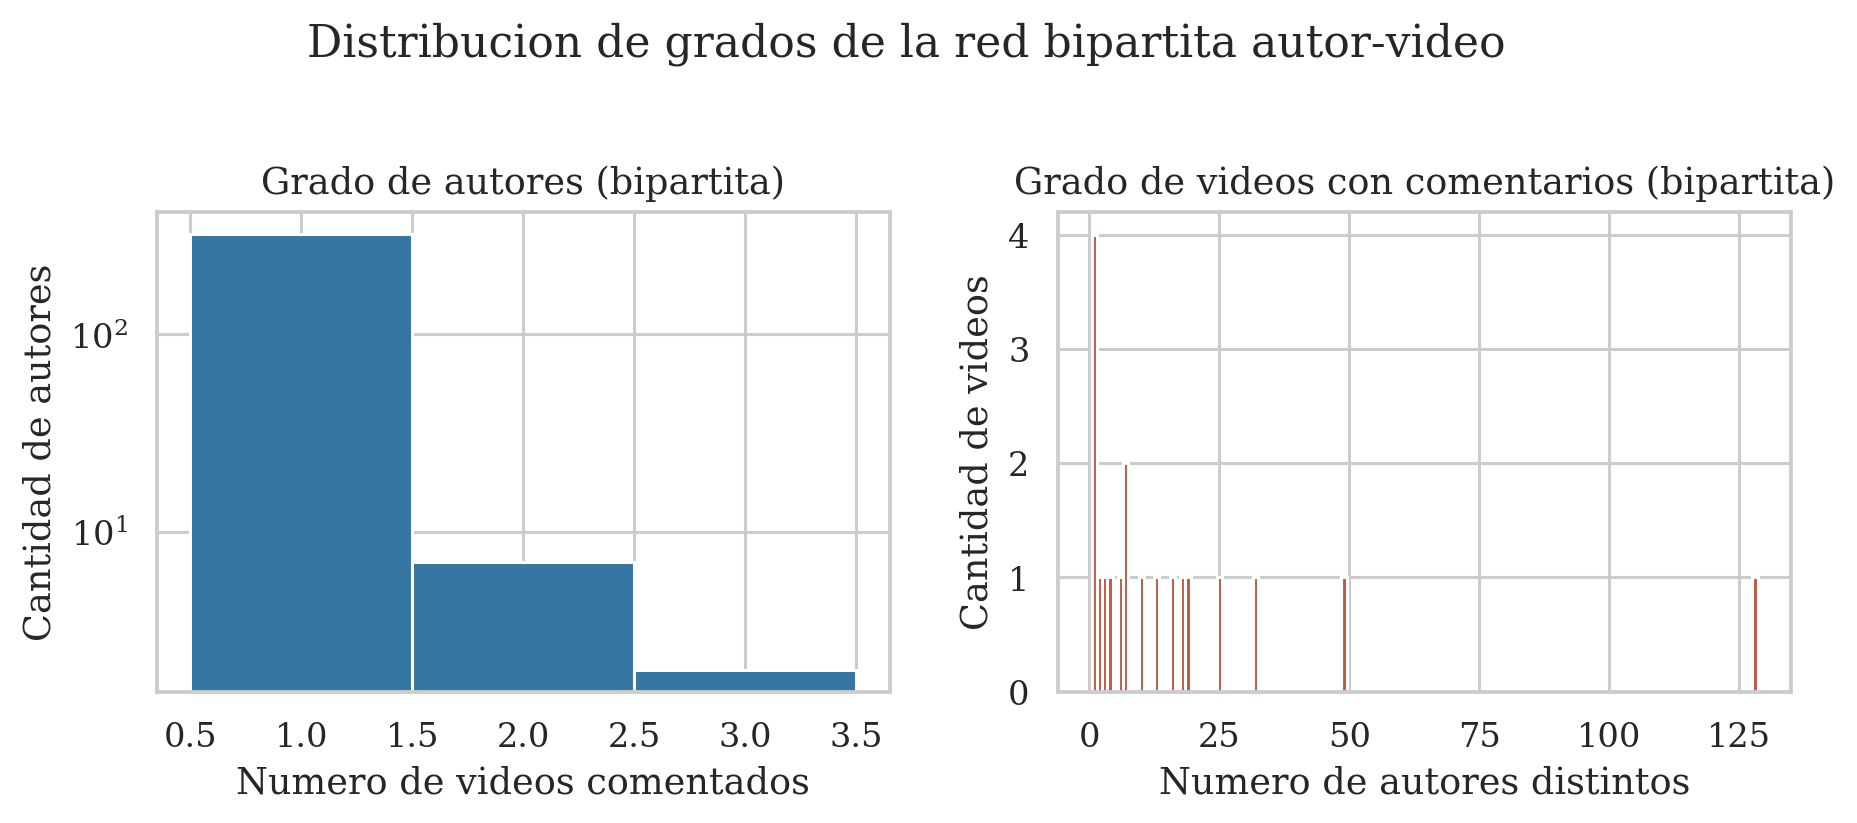

In [ ]:
display(Image(filename=str(FIGURES / "08_distribucion_grados_bipartita.png"), width=850))

In [ ]:
def topology_row(G: nx.Graph, nombre: str) -> dict:
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    degrees = [d for _, d in G.degree()]
    avg_degree = float(np.mean(degrees)) if degrees else 0.0
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = len(comps[0]) if comps else 0
    isolates = sum(1 for d in degrees if d == 0)
    return {
        "red": nombre, "nodos": n, "aristas": m, "densidad": density,
        "grado_medio": avg_degree, "grado_maximo": max(degrees) if degrees else 0,
        "componentes": len(comps), "tamano_componente_mayor": giant,
        "pct_componente_mayor": 100 * giant / n if n else 0,
        "nodos_aislados": isolates,
    }


topology = pd.DataFrame([
    topology_row(B, "bipartita autor-video"),
    topology_row(AA, "proyeccion autor-autor"),
    topology_row(VV, "proyeccion video-video"),
])
topology.to_csv(TABLES / "topologia_redes.csv", index=False, encoding="utf-8-sig")
print(topology.to_string(index=False))

# Cohesion y transitividad
bipartite_clustering_avg = float(np.mean(list(nx.bipartite.clustering(B).values()))) if B.number_of_edges() else 0.0
robins_alexander = float(nx.bipartite.robins_alexander_clustering(B)) if B.number_of_edges() else 0.0
aa_transitivity = float(nx.transitivity(AA))
aa_avg_clustering = float(nx.average_clustering(AA))
vv_transitivity = float(nx.transitivity(VV))
vv_avg_clustering = float(nx.average_clustering(VV))

cohesion = pd.DataFrame([
    {"red": "bipartita autor-video", "medida": "clustering bipartito promedio (nx.bipartite.clustering)", "valor": bipartite_clustering_avg},
    {"red": "bipartita autor-video", "medida": "Robins-Alexander bipartite clustering", "valor": robins_alexander},
    {"red": "proyeccion autor-autor", "medida": "transitividad", "valor": aa_transitivity},
    {"red": "proyeccion autor-autor", "medida": "clustering promedio", "valor": aa_avg_clustering},
    {"red": "proyeccion video-video", "medida": "transitividad", "valor": vv_transitivity},
    {"red": "proyeccion video-video", "medida": "clustering promedio", "valor": vv_avg_clustering},
])
cohesion.to_csv(TABLES / "cohesion_transitividad.csv", index=False, encoding="utf-8-sig")
print(cohesion.to_string(index=False))

# Periferia / aislados
video_degree_bp = {n: B.degree(n) for n in video_nodes}
author_degree_bp = {n: B.degree(n) for n in author_nodes}
videos_sin_comentarios_en_archivo = sum(1 for d in video_degree_bp.values() if d == 0)
authors_una_sola_vez = sum(1 for d in author_degree_bp.values() if d == 1)

periphery = pd.DataFrame([
    {"elemento": "Videos sin comentarios en el archivo (grado 0 en bipartita)", "cantidad": videos_sin_comentarios_en_archivo},
    {"elemento": "Autores que comentaron una sola vez (grado 1 en bipartita)", "cantidad": authors_una_sola_vez},
    {"elemento": "Autores aislados en proyeccion autor-autor (sin coparticipacion)", "cantidad": sum(1 for _, d in AA.degree() if d == 0)},
    {"elemento": "Videos aislados en proyeccion video-video (sin audiencia compartida)", "cantidad": sum(1 for _, d in VV.degree() if d == 0)},
])
periphery.to_csv(TABLES / "periferia_aislados.csv", index=False, encoding="utf-8-sig")
print(periphery.to_string(index=False))

                   red  nodos  aristas  densidad  grado_medio  grado_maximo  componentes  tamano_componente_mayor  pct_componente_mayor  nodos_aislados
 bipartita autor-video    625      343  0.001759     1.097600           128          284                      286             45.760000             274
proyeccion autor-autor    332    10732  0.195319    64.650602           183           10                      276             83.132530               4
proyeccion video-video    293       11  0.000257     0.075085             4          284                       10              3.412969             283


                   red                                                  medida    valor
 bipartita autor-video clustering bipartito promedio (nx.bipartite.clustering) 0.500970
 bipartita autor-video                   Robins-Alexander bipartite clustering 0.007626
proyeccion autor-autor                                           transitividad 0.984025
proyeccion autor-autor                                     clustering promedio 0.972049
proyeccion video-video                                           transitividad 0.315789
proyeccion video-video                                     clustering promedio 0.009670
                                                            elemento  cantidad
         Videos sin comentarios en el archivo (grado 0 en bipartita)       274
          Autores que comentaron una sola vez (grado 1 en bipartita)       323
    Autores aislados en proyeccion autor-autor (sin coparticipacion)         4
Videos aislados en proyeccion video-video (sin audiencia compartida)

In [ ]:
display(topology)
display(cohesion)
display(periphery)

,red,nodos,aristas,densidad,grado_medio,grado_maximo,componentes,tamano_componente_mayor,pct_componente_mayor,nodos_aislados
0,bipartita autor-video,625,343,0.001759,1.097600,128,284,286,45.760000,274
1,proyeccion autor-autor,332,10732,0.195319,64.650602,183,10,276,83.132530,4
2,proyeccion video-video,293,11,0.000257,0.075085,4,284,10,3.412969,283


,red,medida,valor
0,bipartita autor-video,clustering bipartito promedio (nx.bipartite.cl...,0.500970
1,bipartita autor-video,Robins-Alexander bipartite clustering,0.007626
2,proyeccion autor-autor,transitividad,0.984025
3,proyeccion autor-autor,clustering promedio,0.972049
4,proyeccion video-video,transitividad,0.315789
5,proyeccion video-video,clustering promedio,0.009670


,elemento,cantidad
0,Videos sin comentarios en el archivo (grado 0 ...,274
1,Autores que comentaron una sola vez (grado 1 e...,323
2,Autores aislados en proyeccion autor-autor (si...,4
3,Videos aislados en proyeccion video-video (sin...,283


### Hallazgos estructurales

**Red bipartita (625 nodos, 343 aristas):** la densidad es muy baja (0.0018) y el grado medio apenas supera 1. Hay **284 componentes conexos**; el mayor concentra el 45.8 % de los nodos (286 de 625) y el resto son componentes minúsculos o videos aislados. La distribución de grados es fuertemente asimétrica: la mayoría de autores (323 de 332) comentó una sola vez, mientras que unos pocos videos concentran decenas de comentaristas (el máximo es 128).

**Proyección autor-autor (332 nodos, 10,732 aristas):** aquí la densidad sube a 0.195 y la componente mayor cubre el 83.1 % de los autores (276 de 332); solo 4 autores quedan aislados (los que comentaron en videos sin coincidencia con nadie más). La transitividad es muy alta (0.984): esto **no** refleja cohesión social genuina, sino un artefacto propio de proyectar una red bipartita dominada por pocos videos con muchos comentaristas — cada video crea una casi-clique perfecta entre sus autores.

**Proyección video-video (293 nodos, 11 aristas):** es casi completamente fragmentada; 283 videos quedan sin ninguna arista y la componente mayor conexa solo une 10 videos.

**Cohesión:** el coeficiente de clustering bipartito promedio (0.501) es moderado, pero el coeficiente de Robins-Alexander —diseñado específicamente para bipartitas y más robusto a esta clase de sesgo— es muy bajo (0.008), lo que confirma que la aparente cohesión de la proyección autor-autor es en gran medida un efecto de la construcción de la red y no evidencia de una comunidad densamente interconectada.

**Periferia y aislamiento:** los 274 videos sin comentarios en el archivo y los 4 autores aislados en la proyección autor-autor son *ausencia de datos en la muestra recolectada*, no evidencia de que esos videos o autores estén socialmente aislados en YouTube; la cobertura de comentarios fue selectiva desde la recolección (solo 19 de 293 videos).

## 7. Comunidades

Se selecciona la **componente gigante de la red bipartita autor-video** (286 nodos, la única con estructura suficiente para que la detección de comunidades sea informativa) y se aplica el algoritmo de **Louvain** (`networkx.algorithms.community.louvain_communities`), que maximiza la modularidad de forma jerárquica y admite pesos de arista de manera nativa. Se usa el peso `peso` (número de comentarios del autor en ese video) para que los pares autor-video con más interacción pesen más en la asignación de comunidades. Los 339 nodos restantes de la bipartita (videos sin comentarios y componentes triviales) se excluyen porque no aportan estructura para comparar comunidades.

In [ ]:
from networkx.algorithms.community import louvain_communities, modularity as nx_modularity

# Se trabaja sobre la componente gigante de la red bipartita (con aristas), ponderada por 'peso'.
giant_nodes = components[0]
G_giant = B.subgraph(giant_nodes).copy()
communities = louvain_communities(G_giant, weight="peso", seed=19, resolution=1.0)
communities = sorted(communities, key=len, reverse=True)
mod_score = nx_modularity(G_giant, communities, weight="peso")

community_of = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_of[node] = i

comm_sizes = pd.DataFrame(
    [{"comunidad": i, "nodos": len(c),
      "autores": sum(1 for n in c if n.startswith("a:")),
      "videos": sum(1 for n in c if n.startswith("v:"))}
     for i, c in enumerate(communities)]
).sort_values("nodos", ascending=False)
comm_sizes.to_csv(TABLES / "comunidades_tamanos.csv", index=False, encoding="utf-8-sig")
print(f"Numero de comunidades (componente gigante, n={len(giant_nodes)}): {len(communities)}")
print(f"Modularidad (Louvain, ponderada por peso): {mod_score:.4f}")
print(comm_sizes.head(10).to_string(index=False))

Numero de comunidades (componente gigante, n=286): 8
Modularidad (Louvain, ponderada por peso): 0.7038
 comunidad  nodos  autores  videos
         0    125      124       1
         1     48       47       1
         2     32       29       3
         3     31       30       1
         4     20       19       1
         5     14       13       1
         6      8        7       1
         7      8        7       1


In [ ]:
display(comm_sizes)

,comunidad,nodos,autores,videos
0,0,125,124,1
1,1,48,47,1
2,2,32,29,3
3,3,31,30,1
4,4,20,19,1
5,5,14,13,1
6,6,8,7,1
7,7,8,7,1


In [ ]:
palette = ["#3676a3", "#c05b43", "#5a9e6f", "#b08fc7", "#d9a441", "#7d7d7d", "#54c1c9", "#e06377", "#9c8b3f"]
pos_giant = nx.spring_layout(G_giant, seed=19, k=max(0.10, 2.1 / np.sqrt(len(G_giant))), weight="peso", iterations=150)
plt.figure(figsize=(9.5, 7.5))
nx.draw_networkx_edges(G_giant, pos_giant, alpha=0.18, width=0.35, edge_color="#777777")
for i, comm in enumerate(communities):
    nodelist = list(comm)
    shapes = [n for n in nodelist if n.startswith("v:")]
    circles = [n for n in nodelist if n.startswith("a:")]
    color = palette[i % len(palette)]
    if circles:
        nx.draw_networkx_nodes(G_giant, pos_giant, nodelist=circles, node_size=16, node_color=color, alpha=0.85, linewidths=0, label=f"Comunidad {i}")
    if shapes:
        nx.draw_networkx_nodes(G_giant, pos_giant, nodelist=shapes, node_size=42, node_color=color, node_shape="s", alpha=0.95, linewidths=0.6, edgecolors="black")
plt.legend(frameon=False, loc="lower left", fontsize=7, ncol=2)
plt.title(f"Comunidades detectadas (Louvain) — {len(communities)} comunidades, modularidad={mod_score:.3f}")
plt.axis("off")
savefig("11_comunidades_bipartita.png")

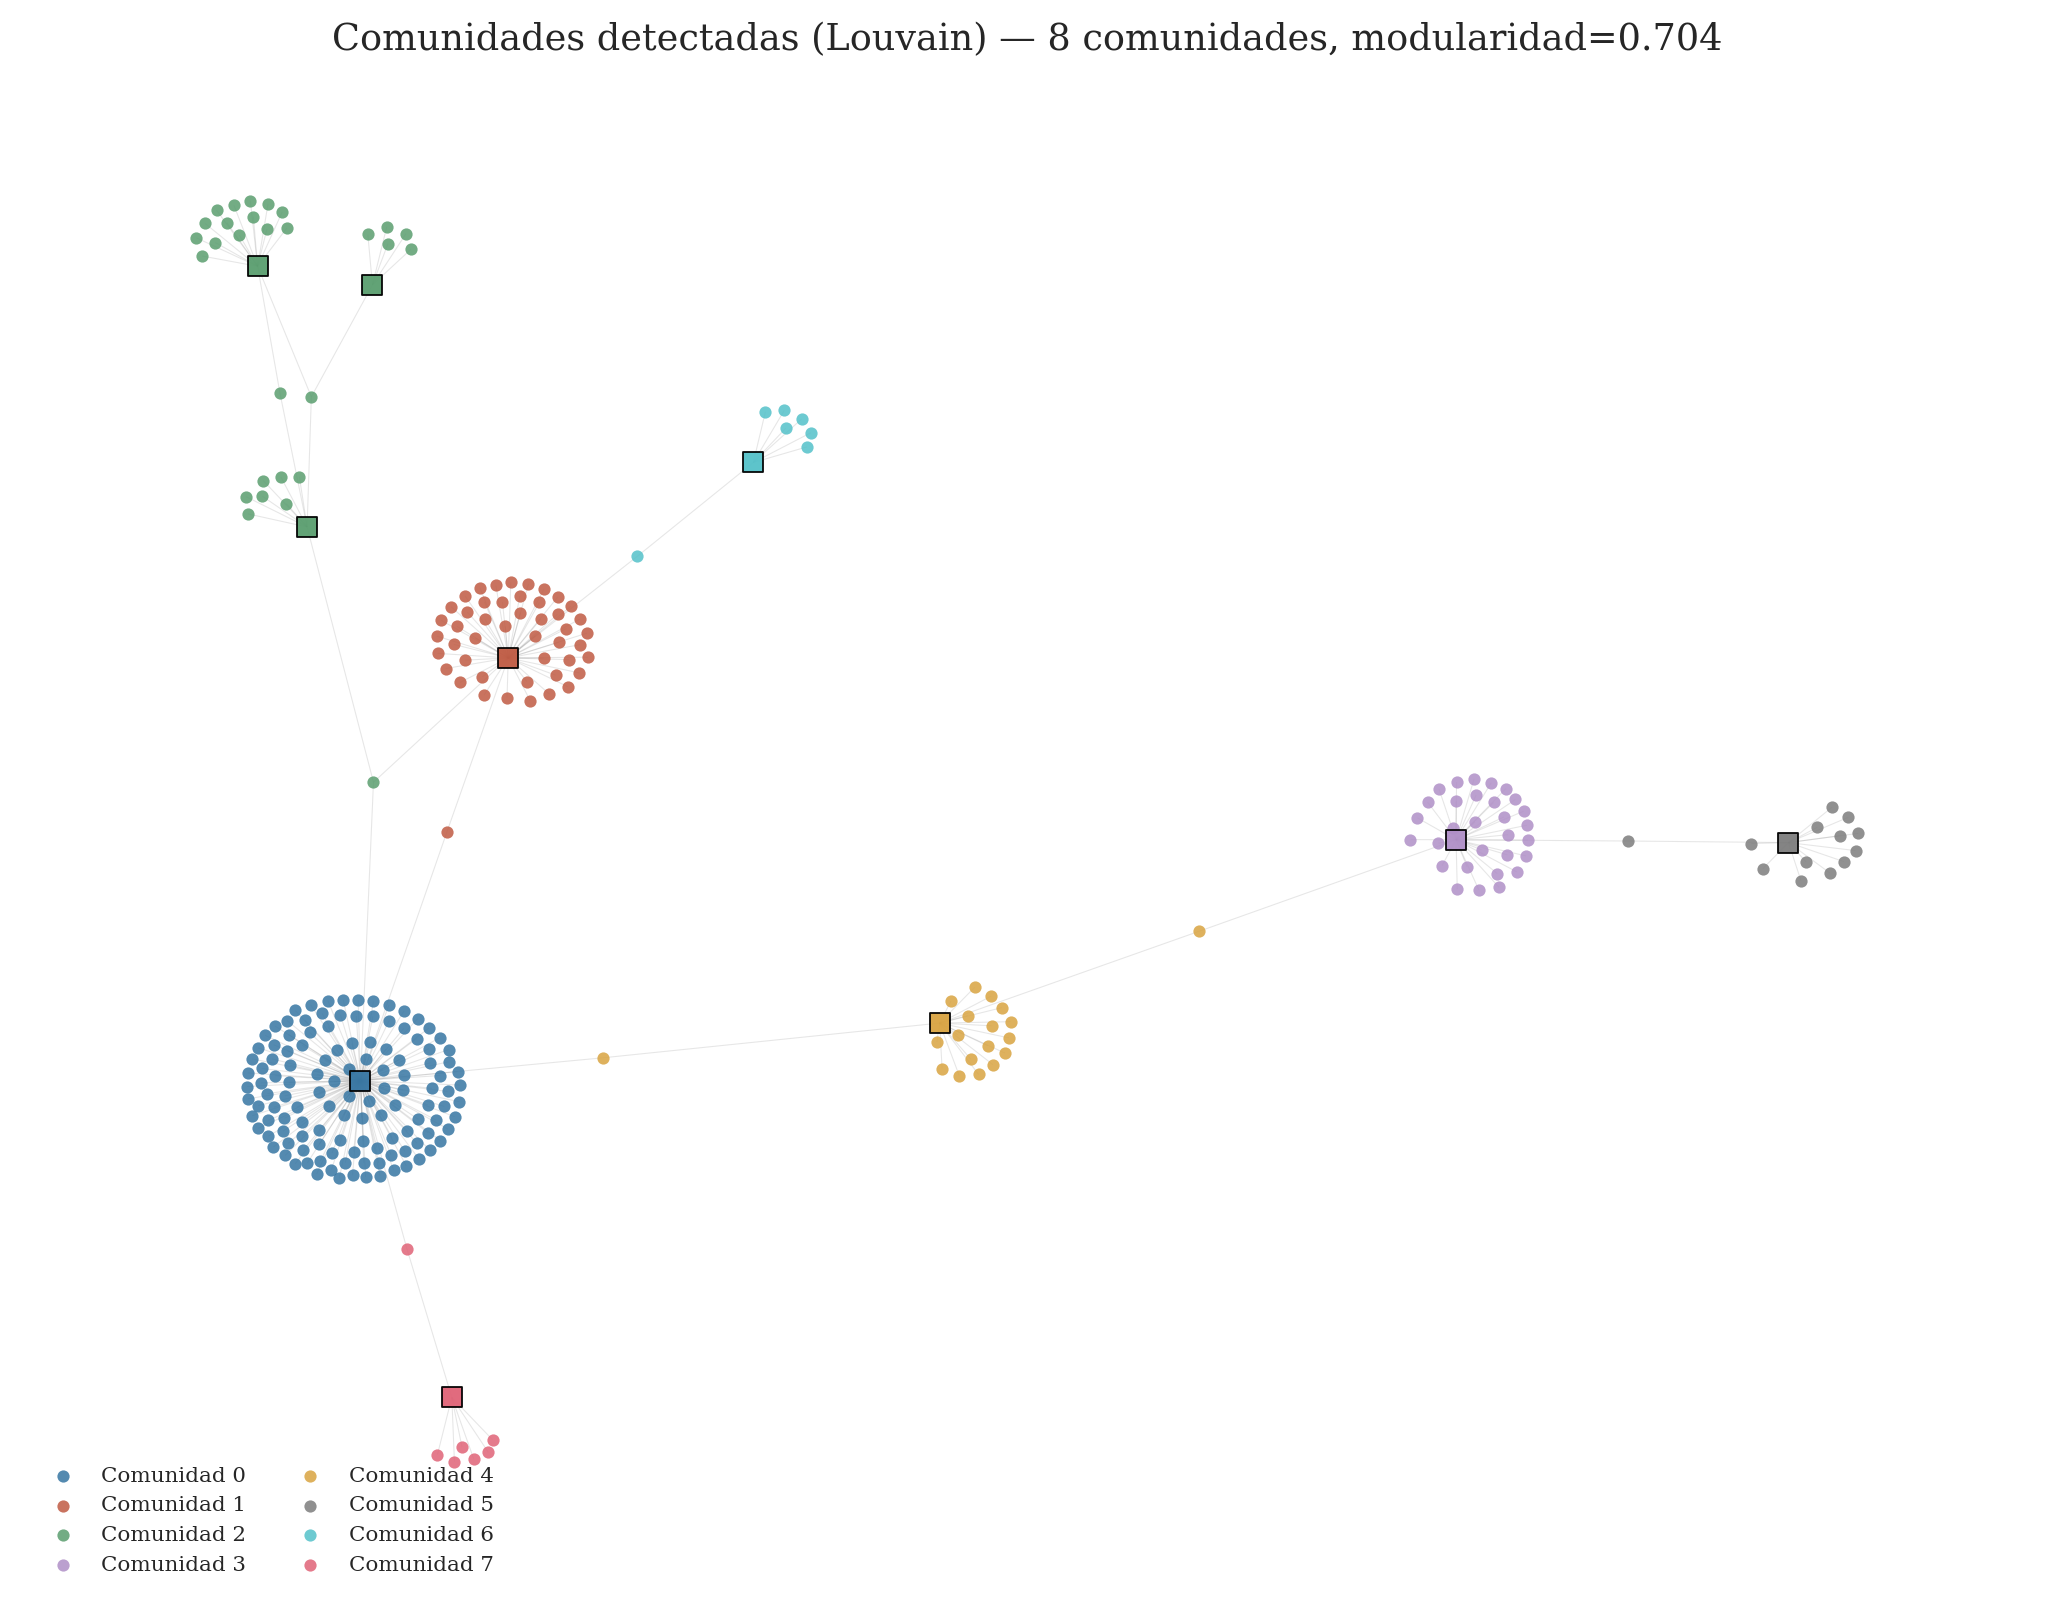

In [ ]:
display(Image(filename=str(FIGURES / "11_comunidades_bipartita.png"), width=950))

### Análisis de las tres comunidades principales

Louvain encontró **8 comunidades** dentro de la componente gigante, con una modularidad de **0.704** (valor alto, aunque hay que interpretarlo con cautela: dado que la componente gigante es casi un árbol de estrellas —cada video conecta a sus propios comentaristas y hay pocos puentes entre videos—, casi cualquier partición que respete esas estrellas obtiene modularidad alta).

- **Comunidad 0** (125 nodos: 124 autores + 1 video): corresponde casi en su totalidad a *"Qué rico come tu diputado"* (Quorum), el video con más comentarios (161) y el que domina la componente gigante. El sentimiento promedio de sus comentarios es el más negativo de todas las comunidades (-0.253), coherente con el vocabulario de queja hacia diputados detectado en el avance.
- **Comunidad 1** (48 nodos: 47 autores + 1 video): agrupa a los comentaristas de *"La cooptación de Walter Mazariegos en la USAC"* (Quorum, 50 comentarios). Su sentimiento promedio es prácticamente neutro (0.010).
- **Comunidad 2** (32 nodos: 29 autores + **3 videos**): es la única comunidad con más de un video, lo que indica que agrupa a los pocos autores que sí generaron puentes entre contenidos (p. ej. quienes comentaron tanto en "Internet: escoger el menos malo" como en "Arroz con pollo a la MONOPOLIO"). Es también la comunidad con el sentimiento promedio más positivo (0.472).

Las comunidades restantes (3 a 7, de 8 a 31 nodos) siguen el mismo patrón: un video dominante con sus comentaristas, prácticamente sin solaparse con otras comunidades. Esto es consistente con lo observado en las proyecciones: la co-participación entre videos es marginal, así que las comunidades terminan coincidiendo casi uno a uno con los videos más comentados.

## 8. Nodos centrales y participantes puente

Sobre la red bipartita completa se calculan grado, grado ponderado (por número de comentarios), **centralidad de intermediación** (*betweenness*, sin ponderar por peso porque el peso representa intensidad de interacción y no una distancia recorrible), **cercanía** y **PageRank ponderado por peso** (complementa el grado con la idea de que un nodo es importante si está conectado a otros nodos importantes).

In [ ]:
deg_cent = nx.degree_centrality(B)
wdeg = dict(B.degree(weight="peso"))
betw_cent = nx.betweenness_centrality(B, weight=None, normalized=True, seed=19)  # unweighted (peso no es distancia)
close_cent = nx.closeness_centrality(B)
pagerank = nx.pagerank(B, weight="peso")

centrality_rows = []
for n in B.nodes():
    centrality_rows.append({
        "node_id": n, "tipo": B.nodes[n]["tipo"],
        "etiqueta": B.nodes[n].get("etiqueta", ""),
        "grado": B.degree(n), "grado_ponderado": wdeg[n],
        "grado_centralidad": deg_cent[n], "intermediacion": betw_cent[n],
        "cercania": close_cent[n], "pagerank": pagerank[n],
        "es_articulacion": n in articulation,
        "comunidad": community_of.get(n, -1),
    })
centrality_table = pd.DataFrame(centrality_rows)
centrality_table.to_csv(TABLES / "centralidad_bipartita.csv", index=False, encoding="utf-8-sig")

top_authors_centrality = centrality_table[centrality_table["tipo"] == "autor"].sort_values("intermediacion", ascending=False).head(10)
top_videos_centrality = centrality_table[centrality_table["tipo"] == "video"].sort_values("pagerank", ascending=False).head(10)
print("Autores con mayor intermediacion:")
print(top_authors_centrality[["etiqueta", "grado", "intermediacion", "pagerank"]].to_string(index=False))
print("\nVideos con mayor PageRank:")
print(top_videos_centrality[["etiqueta", "grado", "pagerank"]].to_string(index=False))

bridge_authors_deg = recurring_authors  # ya calculado en el avance (grado>1)
bridge_authors_articulation = [n[2:] for n in articulation_authors]
bridge_authors_betweenness = centrality_table[
    (centrality_table["tipo"] == "autor") & (centrality_table["intermediacion"] > 0)
].sort_values("intermediacion", ascending=False)

print(f"\nAutores puente por recurrencia (>1 video): {len(bridge_authors_deg)}")
print(f"Autores que son puntos de articulacion: {len(bridge_authors_articulation)}")
print(f"Videos que son puntos de articulacion: {len(articulation_videos)}")
print(f"Autores con intermediacion > 0: {len(bridge_authors_betweenness)}")

Autores con mayor intermediacion:
            etiqueta  grado  intermediacion  pagerank
 @virgiliogarcia3039      2        0.072766  0.002722
      @inge_vergueta      3        0.068522  0.002978
        @josegil3813      2        0.055562  0.001861
        @Jel.Awesh.M      2        0.028013  0.003097
       @hashojea7348      3        0.018760  0.004063
@franciscoflores3120      2        0.018192  0.002055
     @Alejandro00710      2        0.010148  0.002198
   @moisesvaldez4043      2        0.010012  0.002219
  @MarcosCarillo-b1r      2        0.010012  0.002417
   @Santiago.Nolasco      1        0.000000  0.001672

Videos con mayor PageRank:
                                                                                         etiqueta  grado  pagerank
                                                                        Qué rico come tu diputado    128  0.149678
                                                    La cooptación de Walter Mazariegos en la USAC     49  0.056545

In [ ]:
display(top_authors_centrality[["etiqueta", "grado", "grado_ponderado", "intermediacion", "pagerank"]])
display(top_videos_centrality[["etiqueta", "grado", "pagerank"]])

,etiqueta,grado,grado_ponderado,intermediacion,pagerank
470,@virgiliogarcia3039,2,3,0.072766,0.002722
423,@inge_vergueta,3,3,0.068522,0.002978
427,@josegil3813,2,2,0.055562,0.001861
512,@Jel.Awesh.M,2,3,0.028013,0.003097
319,@hashojea7348,3,4,0.018760,0.004063
372,@franciscoflores3120,2,2,0.018192,0.002055
474,@Alejandro00710,2,2,0.010148,0.002198
488,@moisesvaldez4043,2,2,0.010012,0.002219
293,@MarcosCarillo-b1r,2,2,0.010012,0.002417
519,@Santiago.Nolasco,1,1,0.000000,0.001672


,etiqueta,grado,pagerank
246,Qué rico come tu diputado,128,0.149678
229,La cooptación de Walter Mazariegos en la USAC,49,0.056545
38,Inician los trabajos de recuperación del Puent...,32,0.038104
239,Plan 2032 Ciudad de Guatemala,25,0.030664
130,EE.UU. envía a mexicanos deportados a Guatemal...,18,0.022464
136,Conferencia de Prensa del Gobierno de Guatemal...,19,0.022278
289,Arroz con pollo a la MONOPOLIO,16,0.018297
4,Capturan a presuntos delincuentes disfrazados ...,13,0.015667
250,Internet: escoger el menos malo,10,0.011884
228,Capturan a ladrón que había quedado grabado mi...,7,0.008824


In [ ]:
top_bridge = bridge_authors_betweenness.nlargest(9, "intermediacion").sort_values("intermediacion")
plt.figure(figsize=(6.8, 4.0))
plt.barh([shorten(x, 30) for x in top_bridge["etiqueta"]], top_bridge["intermediacion"], color="#7b4f9d")
plt.xlabel("Centralidad de intermediacion (normalizada)")
plt.title("Autores puente segun intermediacion en la red bipartita")
savefig("12_centralidad_autores_puente.png")

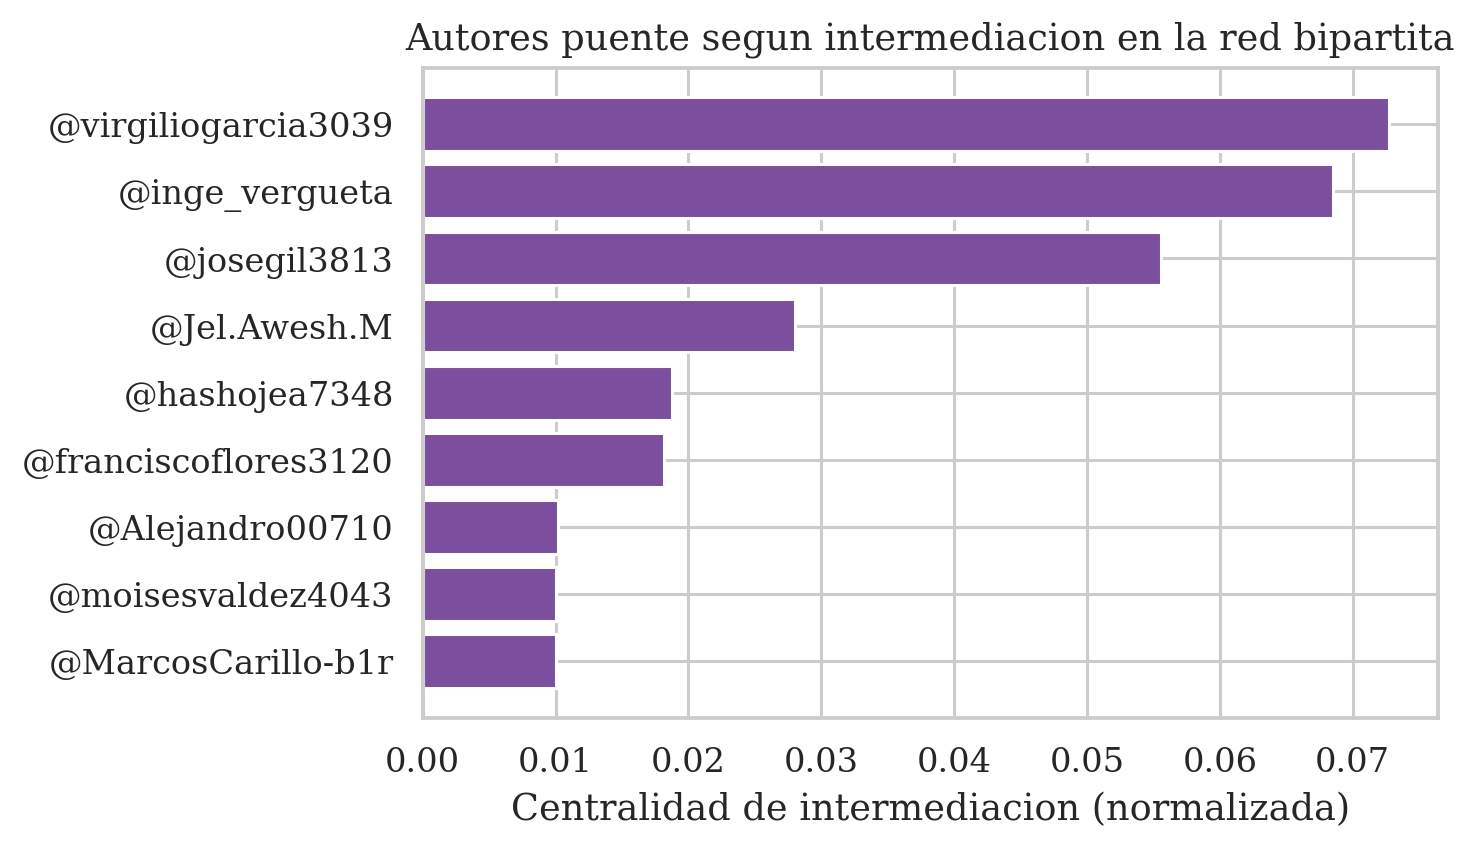

In [ ]:
display(Image(filename=str(FIGURES / "12_centralidad_autores_puente.png"), width=850))

### Interpretación separada para autores y videos

**Autores:** de los 332 autores, solo **9 comentaron en más de un video** (recurrencia, ya identificado en el avance) y son exactamente los únicos con intermediación mayor a 0 en la red bipartita. De ellos, **7 son puntos de articulación** formales (si se eliminaran de la red, esta se fragmentaría más de lo que ya está): destacan `@inge_vergueta` y `@hashojea7348` (3 videos cada uno, los de mayor grado) y `@virgiliogarcia3039` (mayor intermediación individual, 0.073, a pesar de tener grado 2) porque conecta dos componentes que de otro modo permanecerían separados. La diversidad de participación de estos autores es baja: ninguno comentó en más de 3 de los 293 videos, así que 'puente' aquí describe una función estructural puntual, no un patrón de comportamiento recurrente.

**Videos:** el PageRank ponderado confirma la jerarquía ya vista por grado y comentarios: "Qué rico come tu diputado" concentra el mayor alcance dentro de la red (PageRank 0.150, muy por encima del segundo lugar, 0.057), seguido de "La cooptación de Walter Mazariegos en la USAC" y "Inician los trabajos de recuperación del Puente Belice II". De los **15 videos que son puntos de articulación**, la mayoría son precisamente los videos con más autores: si se eliminaran, se desconectarían del componente gigante todos los autores que solo comentaron ahí (que son casi todos).

## 9. Análisis de contenido y sentimiento

**Herramienta y justificación.** Este entorno de trabajo no tiene acceso a internet para descargar modelos preentrenados en español (por ejemplo BETO/`pysentimiento`) ni los recursos adicionales de NLTK (VADER es, además, un léxico calibrado para inglés y no es apropiado para texto en español pese a aparecer sugerido en el enunciado). Por ello se construyó un **analizador de sentimiento basado en léxico en español**, aplicado sobre `texto_original` (no sobre `texto_limpio`, porque este último elimina palabras de negación como "no", que son indispensables para el análisis de polaridad).

El método:
1. Tokeniza el comentario conservando palabras de negación e intensificadores.
2. Cada palabra se busca en un léxico propio de polaridad en español (aprox. 50 palabras positivas y 70 negativas, con vocabulario relevante para el dominio observado: corrupción, injusticia, mentira, etc.).
3. Si dentro de las 3 palabras previas aparece un negador ("no", "nunca", "jamás", "ni", "tampoco", "nadie"), se invierte la polaridad de la palabra encontrada.
4. Si aparece un intensificador ("muy", "tan", "bastante", etc.), se amplifica el peso de esa palabra.
5. El comentario se clasifica como *positivo*, *negativo* o *neutro* según la suma de polaridades.

**Limitación explícita:** el léxico solo detectó al menos una palabra de polaridad en el **38.9 %** de los 406 comentarios; el resto se clasifica como neutro por falta de cobertura léxica, no porque el comentario carezca necesariamente de carga emocional. El método tampoco captura sarcasmo, ironía ni jerga muy específica del español guatemalteco, y su vocabulario fue construido manualmente para este análisis (no validado contra una muestra etiquetada), por lo que sus resultados deben leerse como una aproximación exploratoria y no como una medición definitiva de sentimiento.

In [ ]:
POS_WORDS = {
    "bueno", "buena", "buenos", "buenas", "excelente", "excelentes", "genial",
    "increible", "bendiciones", "bendicion", "gracias", "felicidades", "felicitaciones",
    "esperanza", "orgullo", "orgulloso", "orgullosa", "apoyo", "apoyamos", "viva",
    "vivan", "amor", "hermoso", "hermosa", "grande", "admirable", "justicia",
    "honesto", "honesta", "honestidad", "transparencia", "avance", "mejora",
    "mejorar", "progreso", "adelante", "valiente", "correcto", "correcta",
    "felicito", "bravo", "aplausos", "sabio", "sabia", "inteligente",
    "trabajador", "trabajadora", "positivo", "positiva", "solucion", "unidos",
    "libertad", "paz", "respeto",
}
NEG_WORDS = {
    "corrupto", "corrupta", "corruptos", "corruptas", "corrupcion", "robar",
    "roban", "robo", "robos", "ladron", "ladrones", "ladrona", "verguenza",
    "vergonzoso", "vergonzosa", "injusticia", "injusto", "injusta", "mentira",
    "mentiras", "mentiroso", "mentirosa", "engaño", "engano", "indignante",
    "indignacion", "terrible", "pesimo", "pesima", "horrible", "triste",
    "tristeza", "enojo", "rabia", "asco", "asqueroso", "corrupcion", "fraude",
    "estafa", "estafador", "incompetente", "incompetencia", "inutil",
    "inutiles", "desastre", "desastroso", "pobreza", "hambre", "delincuencia",
    "delincuentes", "criminal", "criminales", "abuso", "abusivo", "abusiva",
    "traicion", "traidor", "traidores", "malo", "mala", "malos", "malas",
    "peor", "odio", "impunidad", "corrupt", "sinverguenza", "sinverguenzas",
    "chatarra", "basura", "payaso", "payasos", "ridiculo", "ridicula",
}
NEGATORS = {"no", "nunca", "jamas", "ni", "tampoco", "nadie"}
INTENSIFIERS = {"muy", "tan", "bastante", "sumamente", "demasiado"}


def sentiment_tokens(value: object) -> list[str]:
    """Tokenizacion ligera que SI conserva negaciones (a diferencia de texto_limpio)."""
    text = str(value)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text, flags=re.I)
    text = re.sub(r"@[\w.\-]+", " ", text)
    text = fold(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return [t for t in text.split() if len(t) > 1]


def lexicon_sentiment(value: object) -> dict:
    tokens = sentiment_tokens(value)
    score = 0
    hits = 0
    for i, tok in enumerate(tokens):
        polarity = 1 if tok in POS_WORDS else (-1 if tok in NEG_WORDS else 0)
        if polarity == 0:
            continue
        window = tokens[max(0, i - 3): i]
        if any(w in NEGATORS for w in window):
            polarity *= -1
        if any(w in INTENSIFIERS for w in window):
            polarity *= 1.5
        score += polarity
        hits += 1
    if hits == 0:
        etiqueta = "neutro"
    elif score > 0:
        etiqueta = "positivo"
    elif score < 0:
        etiqueta = "negativo"
    else:
        etiqueta = "neutro"
    return {"score_sentimiento": score, "palabras_polaridad": hits, "sentimiento": etiqueta}


sent_results = comments["texto_original"].map(lexicon_sentiment).apply(pd.Series)
comments_sent = pd.concat([comments, sent_results], axis=1)
comments_sent.to_csv(TABLES / "comentarios_con_sentimiento.csv", index=False, encoding="utf-8-sig")

sentiment_dist = comments_sent["sentimiento"].value_counts().rename_axis("sentimiento").reset_index(name="comentarios")
sentiment_dist["porcentaje"] = 100 * sentiment_dist["comentarios"] / sentiment_dist["comentarios"].sum()
sentiment_dist.to_csv(TABLES / "distribucion_sentimiento.csv", index=False, encoding="utf-8-sig")
print(sentiment_dist.to_string(index=False))

sentiment_by_video = (
    comments_sent.groupby("video_id")
    .agg(comentarios=("comment_id", "nunique"),
         score_promedio=("score_sentimiento", "mean"),
         positivos=("sentimiento", lambda s: (s == "positivo").sum()),
         negativos=("sentimiento", lambda s: (s == "negativo").sum()),
         neutros=("sentimiento", lambda s: (s == "neutro").sum()))
    .reset_index()
    .merge(videos[["video_id", "title"]], on="video_id", how="left")
    .sort_values("comentarios", ascending=False)
)
sentiment_by_video.to_csv(TABLES / "sentimiento_por_video.csv", index=False, encoding="utf-8-sig")
print(sentiment_by_video.head(10).to_string(index=False))

sentiment_by_channel = (
    comments_sent.groupby("channel_name")
    .agg(comentarios=("comment_id", "nunique"), score_promedio=("score_sentimiento", "mean"))
    .reset_index().sort_values("comentarios", ascending=False)
)
sentiment_by_channel.to_csv(TABLES / "sentimiento_por_canal.csv", index=False, encoding="utf-8-sig")
print(sentiment_by_channel.head(10).to_string(index=False))

# Sentimiento por comunidad (usando el autor del comentario -> comunidad en la red bipartita)
comments_sent["comunidad_autor"] = comments_sent["author_channel_id"].map(
    lambda a: community_of.get(f"a:{a}", -1)
)
sentiment_by_community = (
    comments_sent[comments_sent["comunidad_autor"] >= 0]
    .groupby("comunidad_autor")
    .agg(comentarios=("comment_id", "nunique"), score_promedio=("score_sentimiento", "mean"))
    .reset_index().sort_values("comentarios", ascending=False)
)
sentiment_by_community.to_csv(TABLES / "sentimiento_por_comunidad.csv", index=False, encoding="utf-8-sig")
print(sentiment_by_community.head(10).to_string(index=False))

cobertura_lexico = float((comments_sent["palabras_polaridad"] > 0).mean() * 100)
print(f"\nCobertura del lexico (comentarios con al menos una palabra de polaridad detectada): {cobertura_lexico:.1f}%")

sentimiento  comentarios  porcentaje
     neutro          255   62.807882
   positivo           80   19.704433
   negativo           71   17.487685
   video_id  comentarios  score_promedio  positivos  negativos  neutros                                                                                             title
n8iP75gIpmw          161       -0.251553         15         40      106                                                                         Qué rico come tu diputado
j43HgwYFKfk           50       -0.010000         12         11       27                                                     La cooptación de Walter Mazariegos en la USAC
6W4u8sGEnGM           45        0.077778         13         10       22                                        Inician los trabajos de recuperación del Puente Belice II.
lj983NWyAQY           25        0.600000          9          0       16                                                                     Plan 2032 Ciudad de Guatemala
Pj

In [ ]:
display(sentiment_dist)

,sentimiento,comentarios,porcentaje
0,neutro,255,62.807882
1,positivo,80,19.704433
2,negativo,71,17.487685


In [ ]:
plt.figure(figsize=(5.4, 3.8))
order = ["positivo", "neutro", "negativo"]
colors_sent = {"positivo": "#4c8c5c", "neutro": "#9c9c9c", "negativo": "#b1493f"}
vals = [sentiment_dist.set_index("sentimiento")["comentarios"].get(o, 0) for o in order]
plt.bar(order, vals, color=[colors_sent[o] for o in order])
for i, v in enumerate(vals):
    plt.text(i, v + 3, str(v), ha="center", fontsize=9)
plt.ylabel("Comentarios")
plt.title("Distribucion de sentimiento (lexico en español)")
savefig("13_distribucion_sentimiento.png")

In [ ]:
top_sent_video = sentiment_by_video.nlargest(10, "comentarios").sort_values("score_promedio")
plt.figure(figsize=(7.2, 4.4))
bar_colors = ["#b1493f" if v < 0 else ("#9c9c9c" if v == 0 else "#4c8c5c") for v in top_sent_video["score_promedio"]]
plt.barh([shorten(x, 40) for x in top_sent_video["title"]], top_sent_video["score_promedio"], color=bar_colors)
plt.axvline(0, color="black", linewidth=0.7)
plt.xlabel("Score de sentimiento promedio")
plt.title("Sentimiento promedio en los videos con mas comentarios")
savefig("14_sentimiento_por_video.png")

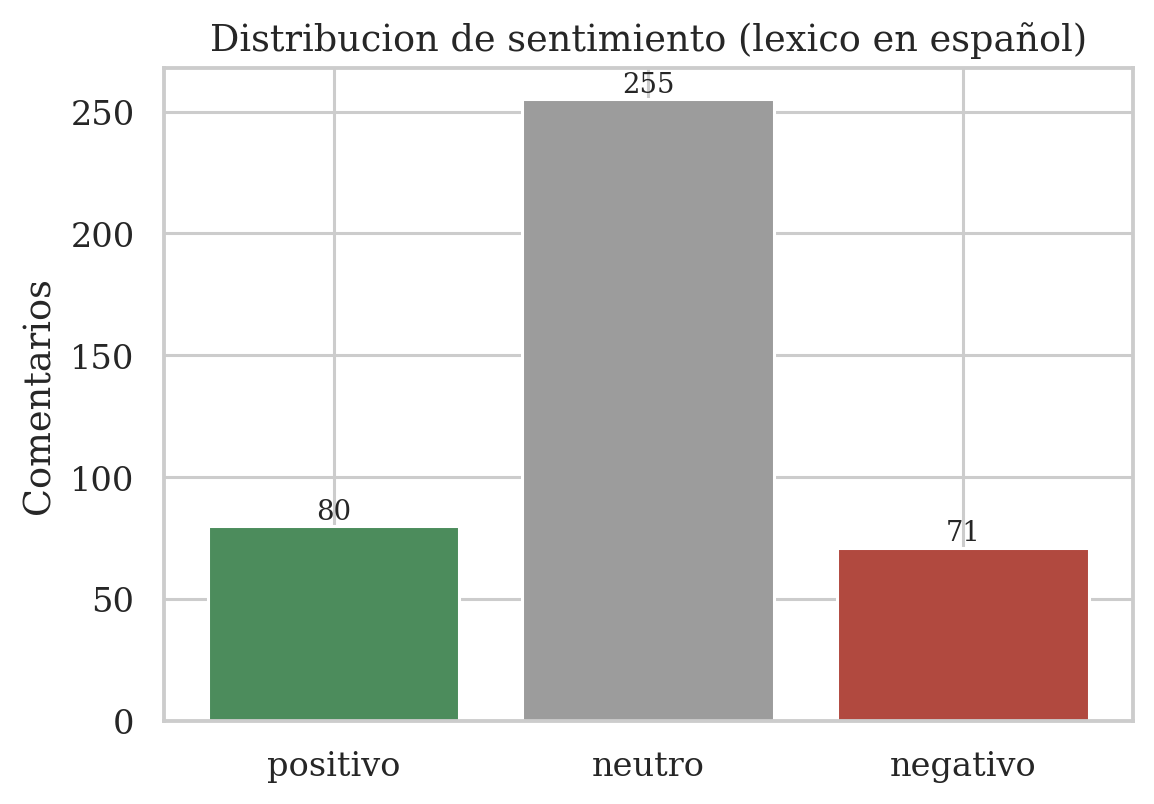

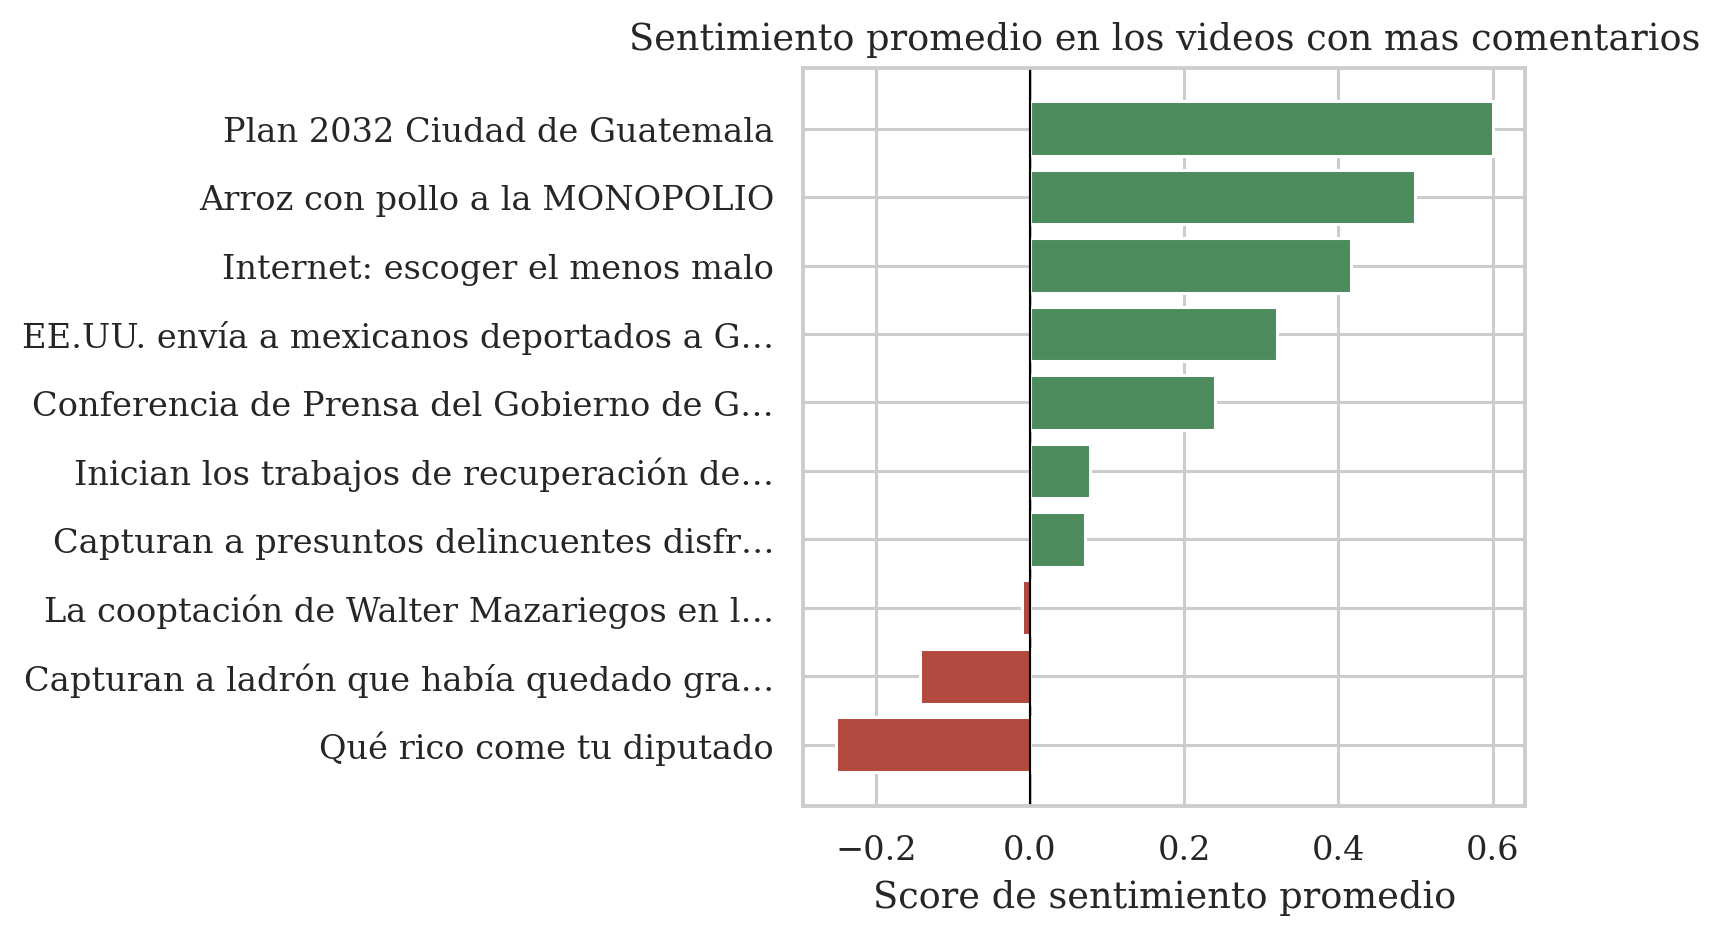

In [ ]:
display(Image(filename=str(FIGURES / "13_distribucion_sentimiento.png"), width=650))
display(Image(filename=str(FIGURES / "14_sentimiento_por_video.png"), width=850))

In [ ]:
display(sentiment_by_video.head(10)[["title", "comentarios", "score_promedio", "positivos", "negativos", "neutros"]])
display(sentiment_by_channel[["channel_name", "comentarios", "score_promedio"]])
display(sentiment_by_community)

,title,comentarios,score_promedio,positivos,negativos,neutros
14,Qué rico come tu diputado,161,-0.251553,15,40,106
12,La cooptación de Walter Mazariegos en la USAC,50,-0.010000,12,11,27
2,Inician los trabajos de recuperación del Puent...,45,0.077778,13,10,22
13,Plan 2032 Ciudad de Guatemala,25,0.600000,9,0,16
5,Conferencia de Prensa del Gobierno de Guatemal...,25,0.240000,5,1,19
4,EE.UU. envía a mexicanos deportados a Guatemal...,25,0.320000,6,2,17
17,Arroz con pollo a la MONOPOLIO,16,0.500000,5,0,11
0,Capturan a presuntos delincuentes disfrazados ...,14,0.071429,2,1,11
15,Internet: escoger el menos malo,12,0.416667,5,2,5
11,Capturan a ladrón que había quedado grabado mi...,7,-0.142857,0,1,6


,channel_name,comentarios,score_promedio
6,Quorum,256,-0.082031
0,Gobierno de la República de Guatemala,70,0.135714
3,Noticias Telemundo,25,0.320000
1,Municipalidad de Guatemala,25,0.600000
2,Noti7,14,0.071429
5,PrensaLibreOficial,7,0.000000
7,TN23 Guatemala,7,-0.142857
4,Noticiero Guatevisión 13 Hrs.,2,-0.500000


,comunidad_autor,comentarios,score_promedio
0,0,156,-0.253205
1,1,49,0.010204
3,3,43,0.058140
2,2,36,0.472222
4,4,28,0.178571
5,5,15,0.133333
6,6,8,-0.250000
7,7,8,0.000000


### Hallazgos de contenido y sentimiento

De los 406 comentarios, el **62.8 % se clasificó como neutro** (255), **19.7 % como positivo** (80) y **17.5 % como negativo** (71); dado el límite de cobertura léxica explicado arriba, esta proporción de neutros está inflada por comentarios cortos sin vocabulario detectado, más que por ausencia real de opinión.

**Por video:** el video más comentado, *"Qué rico come tu diputado"*, tiene el sentimiento promedio más negativo entre los más activos (-0.252, con 40 comentarios negativos contra solo 15 positivos), coherente con las palabras más frecuentes del avance ("corruptos", "dinero", "pacto corruptos"). En contraste, *"Plan 2032 Ciudad de Guatemala"* (Municipalidad de Guatemala) tiene el promedio más positivo entre los videos con más comentarios (0.600, sin ningún comentario negativo detectado).

**Por canal:** Quorum, el canal con más comentarios (256), tiene un promedio ligeramente negativo (-0.082); en cambio, canales institucionales como la Municipalidad de Guatemala (0.600) y Noticias Telemundo (0.320) muestran promedios positivos, aunque con muestras mucho más pequeñas (25 comentarios cada uno) que limitan la generalización.

**Por comunidad:** el patrón es consistente con el de videos, porque cada comunidad principal está dominada por un solo video (ejercicio 7): la comunidad 0 ("Qué rico come tu diputado") es la más negativa (-0.253) y la comunidad 2 (la única con varios videos y autores puente) es la más positiva (0.472), aunque con una muestra mucho menor (36 comentarios).

## 10. Interpretación, limitaciones y conclusiones

### 10.1 Hallazgos en el contexto de participación y consumo de contenido

La muestra recolectada retrata un patrón de participación **muy concentrado y poco recurrente**: 293 videos y 97 canales, pero comentarios observados en solo 19 videos y concentrados en 5 de ellos (75.4 % de los comentarios) y en un solo canal, Quorum (63.1 %). La gran mayoría de autores (97.3 %) comentó una sola vez y no volvió a aparecer en otro video de la muestra. La estructura de red resultante —una bipartita con 284 componentes, dominada por unas pocas estrellas grandes— y las comunidades detectadas (que coinciden casi uno a uno con videos individuales) describen consistentemente un consumo de contenido **fragmentado por pieza**, no una audiencia interconectada que discute across varios videos o canales. El sentimiento, con un tono mixto pero con inclinación negativa en el contenido político de mayor participación (Quorum, diputados), es congruente con el vocabulario de queja identificado desde el avance.

### 10.2 Limitaciones de la recolección y la cobertura

- **Cobertura de comentarios:** solo 19 de 293 videos (6.5 %) tienen comentarios en el archivo; los 274 restantes son ausencia de datos observados, no evidencia de que no existan comentarios en YouTube.
- **Selección por consultas:** `source_query` y `source_group` documentan cómo se buscaron los videos (cuentas gubernamentales, términos como "guatemala noticias/transporte/tráfico"), no una muestra representativa de YouTube ni de los temas que consume la población guatemalteca.
- **Fechas relativas:** `published_time` y `published_text` son tiempos relativos al momento de recolección; no permiten reconstruir una línea temporal exacta ni analizar tendencias por fecha real.
- **Conteos como fotografía puntual:** vistas, comentarios y "me gusta" reflejan un único momento de captura; los 53 casos donde `view_count_text` no coincidía exactamente con `view_count` (ver avance) ya anticipaban esta inconsistencia temporal.
- **Ausencia de relaciones explícitas entre autores:** `reply_count` indica cuántas respuestas recibió un comentario, pero no identifica a quién respondió; por diseño del laboratorio, esa variable nunca se usó para construir aristas entre usuarios, y toda arista autor-video representa exclusivamente co-presencia en el mismo contenido.
- **Concentración en pocos videos:** las métricas de red, comunidades y centralidad están dominadas por un puñado de videos con muchos comentarios; los resultados agregados (por ejemplo, la modularidad alta o la transitividad de la proyección autor-autor) reflejan en buena medida esa concentración y no una propiedad general de "la conversación sobre Guatemala en YouTube".

### 10.3 Descripción, asociación e inferencia

Los resultados presentados son **descriptivos** (conteos, distribución de grados, tamaños de comunidad) o, a lo sumo, **asociativos dentro de la muestra** (por ejemplo, la correlación de Spearman entre vistas y comentarios sube de 0.080 en los 293 videos a 0.811 entre los 19 videos comentados, pero esa diferencia no debe leerse como causal: los comentarios se recolectaron solo para una selección de videos y los conteos corresponden a momentos de captura distintos). Ninguno de estos hallazgos debe generalizarse a todos los usuarios de YouTube ni a toda la población de Guatemala: la muestra fue armada con consultas dirigidas, cubre un número reducido de videos con comentarios y la cadena de causalidad entre visibilidad, participación y sentimiento no puede establecerse con datos observacionales de un único corte temporal.

### 10.4 Conclusiones integradas

Integrando redes, contenido, sentimiento y limitaciones: la participación observada en este conjunto de datos es **concentrada, poco recurrente y fragmentada por contenido**. La red bipartita autor-video, sus proyecciones y las comunidades detectadas describen consistentemente el mismo fenómeno desde ángulos distintos —pocos videos concentran casi toda la actividad, casi ningún autor participa en más de un par de videos, y las pocas comunidades con múltiples videos son la excepción, no la regla—. El análisis de sentimiento, con las limitaciones de cobertura léxica ya señaladas, sugiere que el tono es más negativo en el contenido político de mayor tracción (asociado a corrupción y diputados) y más positivo en contenido institucional de menor escala (obra pública, servicios). Cualquier lectura de estos resultados debe mantenerse acotada a la muestra entregada: no representa a todos los usuarios de YouTube ni permite conclusiones causales sobre el clima de opinión en Guatemala.